In [1]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np
import sr_fun
importlib.reload(sr_fun)
import pandas as pd
import re
import scipy.optimize
from tqdm import tqdm
import corner
import scipy.stats

import fit_curves
importlib.reload(fit_curves)

import sys
sys.path.insert(0, '../literature_fits')
import attenuation_curves, fit_literature

# IOB Fits


Reading from configuration file: conf/iob_35.ini

Reading from configuration file: conf/selection_1.ini

Target: log10A

All model lengths:
[ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34]

Equation requested:
((-0.010842) + (0.908373 * ((tanh(((-0.944124) * X5)) - (-0.748169)) * log((5.327414 + (59.207840 * X1))))))

Equation with pars
0.908373*(0.748169 - tanh(0.944124*lam))*log(59.20784*IOB1 + 5.327414) - 0.010842

Converted equation:
c0*(c1 - tanh(c2*lam))*log(c3*IOB1 + c4) - c5

Number of parameters: 6
Values: [0.908373, 0.748169, 0.944124, 59.20784, 5.327414, 0.010842]



Latex version:
c_{0} \left(c_{1} - \tanh{\left(c_{2} x \right)}\right) \log{\left(I_{1} c_{3} + c_{4} \right)} - c_{5}

Value at x=1:



--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Reparameterising expression:
Original number of parameters: 7
Temporary global prefix: b, temporary local prefix: d
Old local parameters: ['IOB1']
Final number of parameters: 4
Of which global: 3 and local: 1
Final values: [-0.0108420000000000, 0.944124, 0.748169]
Local replacements: {B0: c0*log(IOB1*c3 + c4)}



Latex version:
B_{0} \left(a_{2} - \tanh{\left(a_{1} x \right)}\right) + a_{0}

Value at x=1:


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Generating code...
Saved code to sr_fun.py

Reading from configuration file: conf/iob_35.ini

Reading from configuration file: conf/selection_1.ini

Target: log10A

RMSE train: 3.922e-01
		1 sigma: -0.17988755234409504 0.11763326126738692
		RMSE: 0.14857659563048745
		RMAE: 0.07837559560472782
		1 sigma: -0.09704804069795521 0.18300995247405144
Median absolute DF/F 0.0144085433236123
RMSE DF/F 0.07457914689351065

RMSE val: 3.672e-01
		1 sigma: -0.18503458991618432 0.12888760107428904
		RMSE: 0.14477051142182523
		RMAE: 0.07957079559941034
		1 sigma: -0.09428609193527034 0.17791698051223598
Median absolute DF/F 0.013940449751861095
RMSE DF/F 0.06981819078273681

Reading from configuration file: conf/iob_35.ini

Reading from configuration file: conf/selection_1.ini

Target: log10A


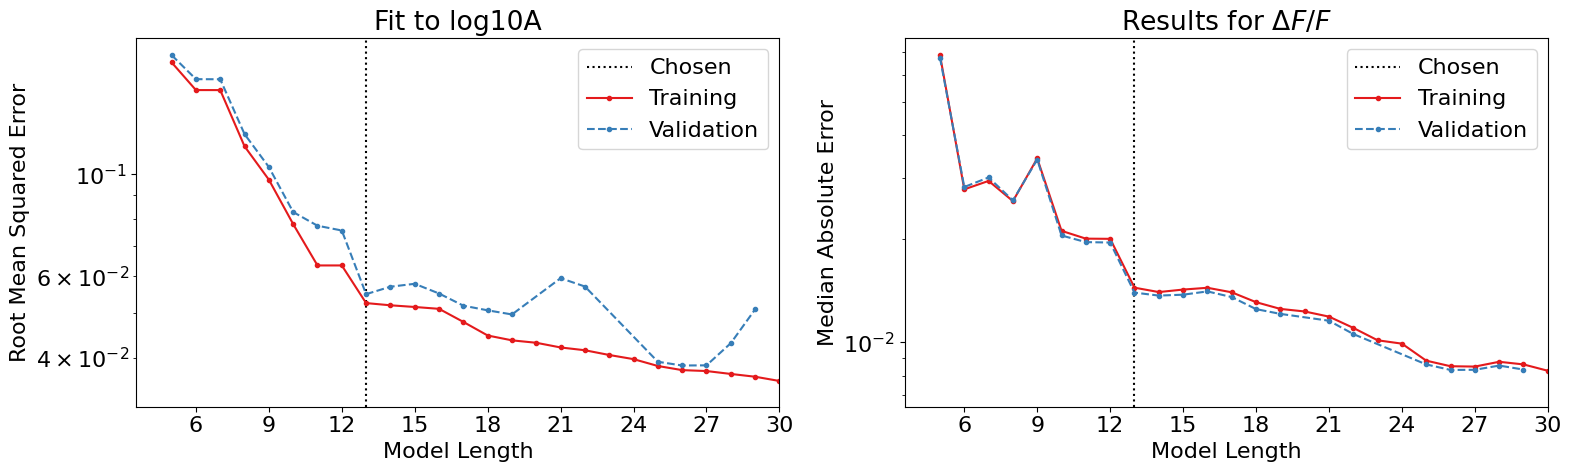

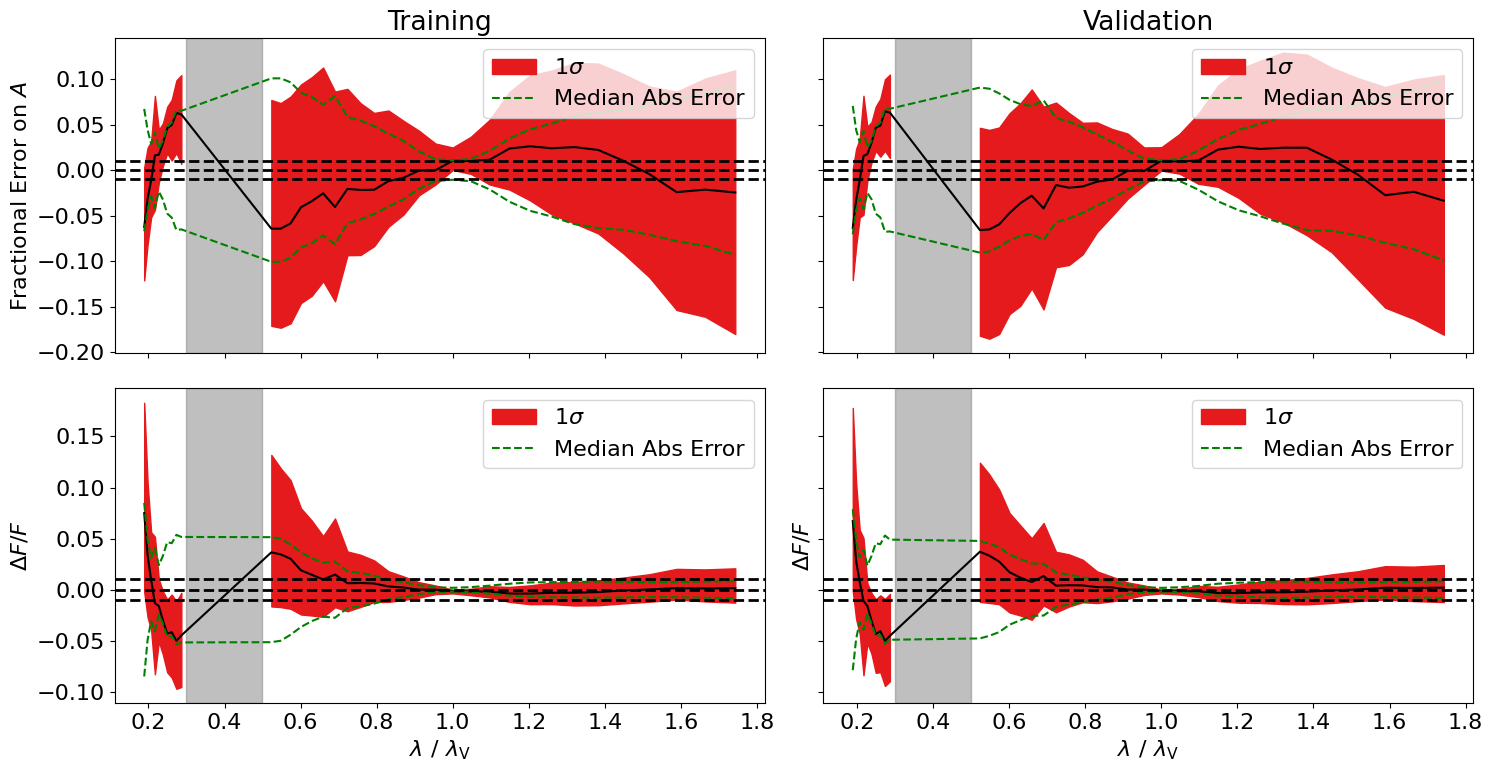

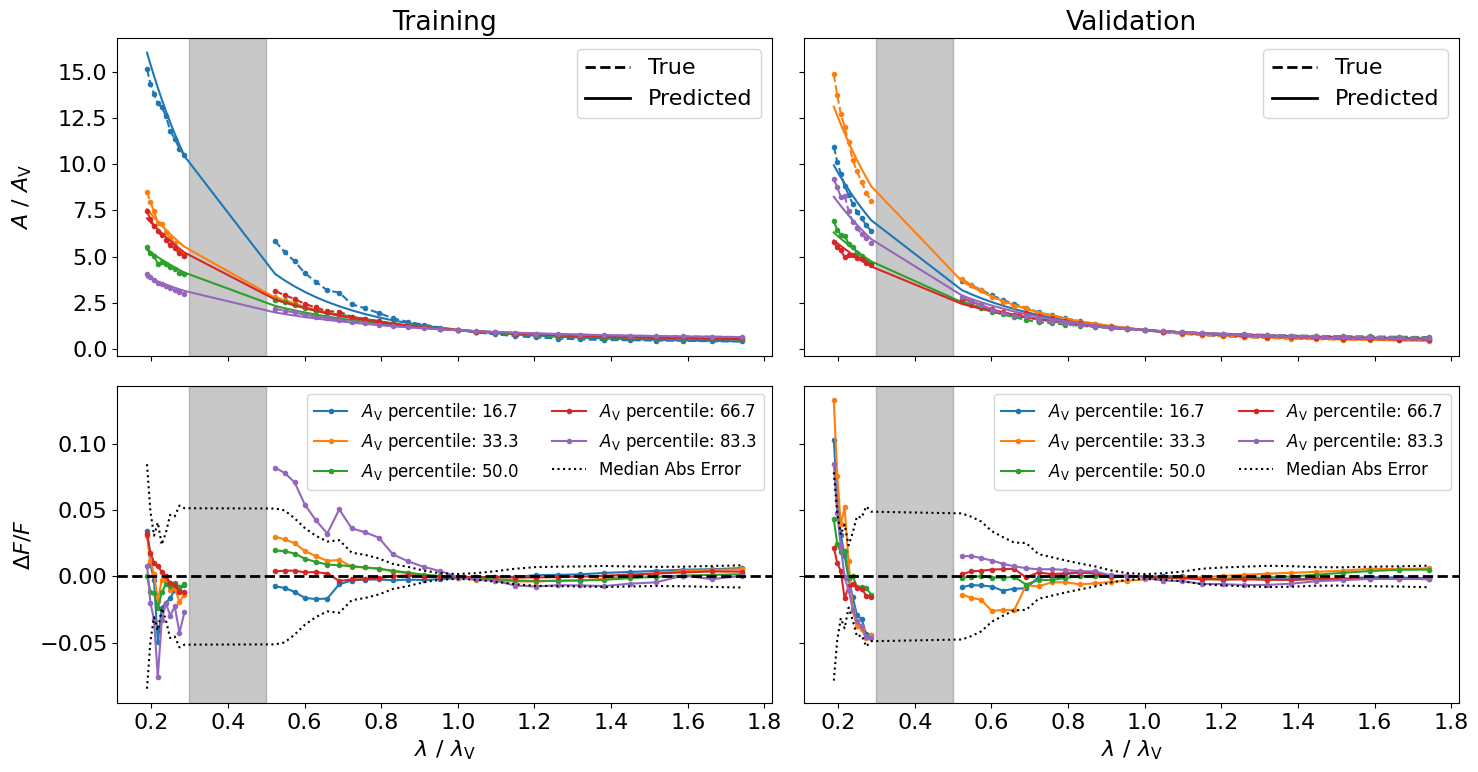

In [ ]:
ini_file = 'conf/iob_0.ini'; ilen = None
ini_file = 'conf/iob_1.ini'; ilen = None
ini_file = 'conf/iob_2.ini'; ilen = None
ini_file = 'conf/iob_3.ini'; ilen = None
ini_file = 'conf/iob_4.ini'; ilen = None
# ini_file = 'conf/iob_5.ini'; ilen = None
# ini_file = 'conf/iob_6.ini'; ilen = None
# ini_file = 'conf/iob_7.ini'; ilen = 40
# ini_file = 'conf/iob_8.ini'; ilen = 29
ini_file = 'conf/iob_9.ini'; ilen = 32; ilen = 13 # No bump

# ini_file = 'conf/iob_10.ini'; ilen = None; ilen = 28 # No bump - remove exp from basis
# ilen = 15

# ini_file = 'conf/iob_11.ini'; ilen = None # Full curve, 24hr
# ini_file = 'conf/iob_12.ini'; ilen = 48 # Full curve, 24hr, add aq to basis
# ini_file = 'conf/iob_13.ini'; ilen = None # Full curve, 48hr
# ini_file = 'conf/iob_14.ini'; ilen = None # Full curve, 48hr, add aq to basis

# ini_file = 'conf/iob_15.ini'; ilen = None; ilen=56  # Full curve, 24hr, linear space
# NOTE: ilen=56 looks like denominator could have a zero, but the minimum of this is
# ~0.0294 at x=0.38 for any x, so it's fine.
# ilen=56 is my favourite up to run 16. Need to check overall minimum etc.
# Problem as x -> inf? Looks like it goes to 1, but wanted 0?
# ilen = 41

# ini_file = 'conf/iob_16.ini'; ilen = None # Full curve, 24hr, add aq to basis, linear space

ini_file = 'conf/iob_17.ini'; ilen = 64 # Full curve, 48hr, linear space
# ini_file = 'conf/iob_18.ini'; ilen = 40 # Full curve, 48hr, linear space

# ini_file = 'conf/iob_19.ini'; ilen = 74
# ini_file = 'conf/iob_20.ini'; ilen = 45
# ini_file = 'conf/iob_21.ini'; ilen = 63

# ini_file = 'conf/iob_22.ini'; ilen = None  # No bump but MSE error

# No bump and short max model length
# ini_file = 'conf/iob_23.ini'; ilen = None
# ini_file = 'conf/iob_24.ini'; ilen = 13
# ini_file = 'conf/iob_25.ini'; ilen = 13
# ini_file = 'conf/iob_26.ini'; ilen = 13
# # ini_file = 'conf/iob_27.ini'; ilen = 14
# ini_file = 'conf/iob_28.ini'; ilen = 19
# ini_file = 'conf/iob_29.ini'; ilen = 15
# # ini_file = 'conf/iob_30.ini'; ilen = 14
# # ilen = 15
# ini_file = 'conf/iob_31.ini'; ilen = 15
# run 32 failed (node error)
ini_file = 'conf/iob_35.ini'; ilen = 13  # THIS IS WHAT IS CHOSEN FOR THE OUTER FUNCTION

# Back to full curve fits with MSE
# ini_file = 'conf/iob_33.ini'; ilen = 65;
# ini_file = 'conf/iob_34.ini'; ilen = 65

# Full curve where we subtract outer first
# ini_file = 'conf/iob_36.ini'; ilen = 35; ilen = 26
# ini_file = 'conf/iob_37.ini'; ilen = 34
# ini_file = 'conf/iob_38.ini'; ilen = None
# ini_file = 'conf/iob_39.ini'; ilen = 36
# ini_file = 'conf/iob_40.ini'; ilen = 41; ilen = 34 # NOT BAD
# ini_file = 'conf/iob_41.ini'; ilen = 36
# ini_file = 'conf/iob_42.ini'; ilen = 38
# ini_file = 'conf/iob_43.ini'; ilen = None
ini_file = 'conf/iob_44.ini'; ilen = 43  # THIS IS WHAT IS CHOSEN FOR THE INNER FUNCTION
# ini_file = 'conf/iob_45.ini'; ilen = 43
# ini_file = 'conf/iob_46.ini'; ilen = 29

args = OperonArgs(ini_file, verbose=False)
processing_fun.plot_pareto(ini_file, ilen=ilen, prefix='c')
processing_fun.prediction_plots(ini_file, ilen=ilen, plot_frac_error=True);
processing_fun.plot_example(ini_file, ilen=ilen, nexamples=5, plot_av_diff=False, plot_dF_F=True, yscale='linear', subtract_outer=args.subtract_outer);
# processing_fun.compare_to_literature(ini_file, ilen=ilen, which_gals='all', use_optimised=False);

Test output code


Reading from configuration file: conf/iob_31.ini

Reading from configuration file: conf/selection_1.ini

Reading from configuration file: conf/iob_31.ini

Reading from configuration file: conf/selection_1.ini
Galaxy ID: 720251.0, LOS: 16.0
IOB values: [-0.028115  0.002932 -0.007467 -0.001387  0.002089 -0.001554  0.000629
 -0.001419]
Computed B parameters: -0.027973047365000003
(1473, 8)
1070
-0.07853446728300001 0.243605792742 0.004746363423809912


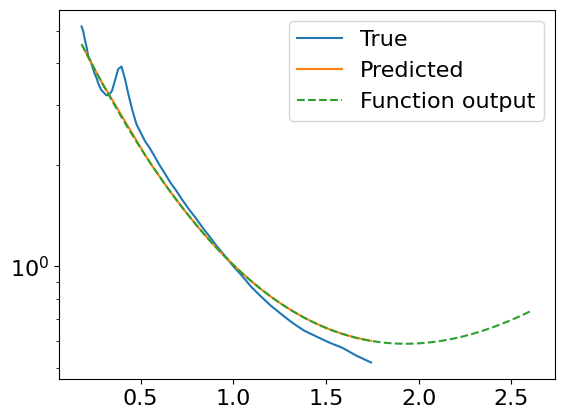

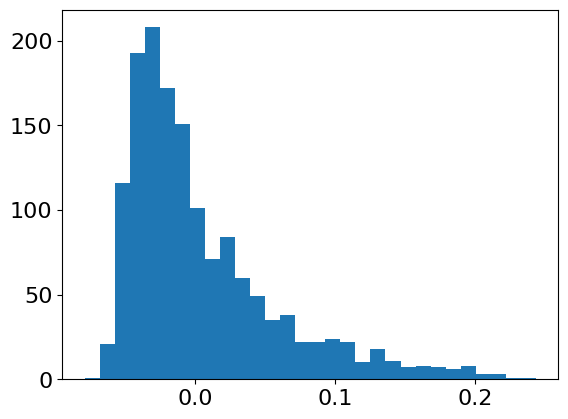

In [45]:
name = 'train'
# ini_file = 'conf/iob_6.ini'; ilen = 32
# ini_file = 'conf/iob_29.ini'; ilen = 15
# ini_file = 'conf/iob_30.ini'; ilen = 14

args = OperonArgs(ini_file)

fname = args.selection.train_file if name == 'train' else args.selection.val_file
data_train = pd.read_csv(fname)
iob_cols = sorted([col for col in data_train.columns if re.match(r'IOB\d+', col)])
lam_cols = [col for col in data_train.columns if re.match(r'A_\d+', col)]
ytrue = data_train[lam_cols].values
A_v_col = f'A_{int(args.lambda_V*1e4)}A'
A_v = data_train[A_v_col].values
lam = np.array([int(re.search(r'_(\d+)', col).group(1)) / 1e4 for col in lam_cols])
x = lam / args.lambda_V

# Get AV
attenuation_cols = [col for col in data_train.columns if re.match(r'A_\d+A', col)]
lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
v_index = processing_fun.find_nearest(lam_arr,0.551)

# Get operon data for prediction
args = OperonArgs(ini_file)
run_name = f'{args.in_param}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = f'{out_dir}/{run_name}_fun.csv'
df = pd.read_csv(fname, delimiter=';')
if ilen is None:
    eq_idx = -1
else:
    eq_idx = list(df['Length']).index(ilen)
length = list(df['Length'])[eq_idx]
fname = f'{out_dir}/{run_name}_{name}_{length}.csv'
data = np.loadtxt(fname)
ypred = data[:,args.npar+2]
dirname = pjoin(args.out_data_dir, f'{args.in_param}_data_{args.version_num}')
fname = pjoin(dirname, f'{args.in_param}_train_data.txt')
with open(fname, 'r') as f:
    header = f.readline().split()
x_sub = np.unique(np.loadtxt(fname, skiprows=1)[:,header.index('lam')])
ypred = ypred.reshape(-1, len(x_sub))

importlib.reload(sr_fun)
xplot = np.linspace(np.min(x), 1.5*np.max(x), 100)

for i in [10]:
    print(f'Galaxy ID: {data_train["galaxy_id"].values[i]}, LOS: {data_train["los"].values[i]}')
    IOB = data_train[iob_cols].values[i]
    print(f"IOB values: {IOB}")
    B = sr_fun.compute_initial_B(IOB)
    print(f'Computed B parameters: {B}')
    if np.isscalar(B):
        B = (B,)
    new_pred = sr_fun.compute_Av(xplot, *B)
    # new_pred = compute_Av(xplot, *B)
    if args.fit_log:
        new_pred = 10. ** new_pred

    plt.plot(x, ytrue[i] / A_v[i], label='True')
    plt.plot(x_sub, ypred[i], label='Predicted')
    plt.plot(xplot, new_pred, label='Function output', ls='--')
    plt.legend()

#     print(np.sqrt(np.mean((new_pred - ypred[i])**2)))
#     print(np.sqrt(np.mean((ypred[i] - ytrue[i])**2)))

plt.yscale('log')

# A_err_op = [None] * getattr(args, f'n{name}')
# df_F_op = [None] * getattr(args, f'n{name}')
# for j in range(getattr(args, f'n{name}')):
#     A_err_op[j] = ypred[j*len(lam):(j+1)*len(lam)] - ytrue[j*len(lam):(j+1)*len(lam)]
#     df_F_op[j] = data[j*len(lam):(j+1)*len(lam),args.npar+3]

# # Get AV
# attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
# lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
# v_index = processing_fun.find_nearest(lam_arr,0.551)
# Av_name = attenuation_cols[v_index]
# Av = data_train[Av_name].values

IOB = data_train[iob_cols].values
print(IOB.shape)
B = sr_fun.compute_initial_B(IOB.T)
print(np.argmax(B))
plt.figure()
plt.hist(B, bins=30)
print(np.min(B), np.max(B), np.mean(B))



Fitted tanh parameters: A=2.262279396227433, B=0.7592281966296044, C=1.2482650712040162
Galaxy ID: 720251.0, LOS: 16.0
IOB values: [-0.028115  0.002932 -0.007467 -0.001387  0.002089 -0.001554  0.000629
 -0.001419]
Computed B parameters: -0.027973047365000003


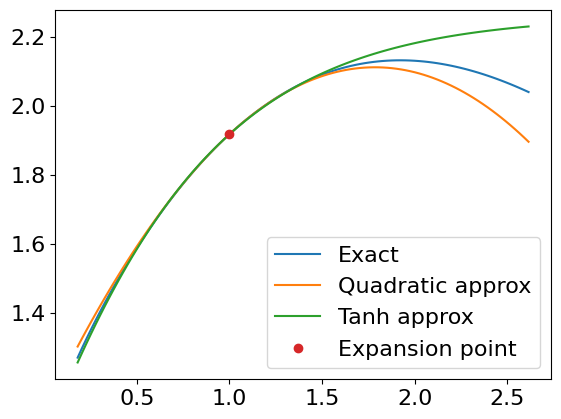

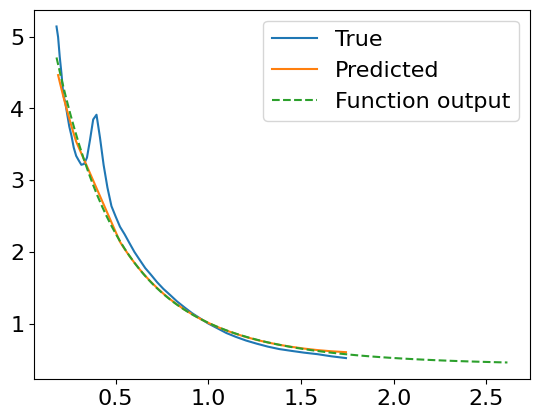

In [61]:
# i = 10
# xplot = np.linspace(np.min(x), 1.5*np.max(x), 100)
# IOB = data_train[iob_cols].values[i]
# print(f"IOB values: {IOB}")
# B = sr_fun.compute_initial_B(IOB)
# a = [-0.0123170000000000, -0.481067000000000, 1.015321, 4.279083, -2.19217600000000, 0.198605]
# # A_over_Av = a[0] + a[2]*(B0 - (a[3]*xplot)**B1)*(a[4] + (a[5]*xplot)**(a[1]*xplot))
# plt.axhline(a[4])
# plt.plot(xplot, (a[5]*xplot)**(a[1]*xplot))

a = [-0.00720300000000000, -0.394022000000000, 0.91748, -1.92882800000000, -2.47409200000000, 6.9e-05, 0.191431]

# Quadratic approximation
a_val = a[6]
b = a[1]

a0 = a_val ** b
a1 = b * (np.log(a_val) + 1) * a_val ** b
a2 = b * a_val ** b * (1 + b * (np.log(a_val) + 1)**2)
h  = xplot - 1

def approx_fun(x, A, B, C):
    return A * np.tanh(B * (x - 1) + C)

# Get approximation as a tanh function
xfit = np.linspace(0.5, 1.5, 50)
y = (a_val*xfit)**(b*xfit)
res = scipy.optimize.curve_fit(approx_fun, xfit, y, p0=[a0, 2., 0])
A_fit, B_fit, C_fit = res[0]
print(f'Fitted tanh parameters: A={A_fit}, B={B_fit}, C={C_fit}')
y_tanh = approx_fun(xplot, A_fit, B_fit, C_fit)

plt.plot(xplot, (a_val*xplot)**(b*xplot), label='Exact')
plt.plot(xplot, a0 + a1*h + 0.5*a2*h**2, label='Quadratic approx')
plt.plot(xplot, y_tanh, label='Tanh approx')
plt.plot([1.], [a0], 'o', label='Expansion point')
plt.legend()

def compute_Av(x, B0):
    a = [-0.00720300000000000, -0.394022000000000, 0.91748, -1.92882800000000, -2.47409200000000, 6.9e-05, 0.191431]
    # A_over_Av = a[0] + a[2]*(a[3] + (a[6]*x)**(a[1]*x))*(a[4] + (a[5]*x)**B0)
    A_over_Av = a[0] + a[2]*(a[3] + approx_fun(x, A_fit, B_fit, C_fit))*(a[4] + (a[5]*x)**B0)
    return A_over_Av

plt.figure()
for i in [10]:
    print(f'Galaxy ID: {data_train["galaxy_id"].values[i]}, LOS: {data_train["los"].values[i]}')
    IOB = data_train[iob_cols].values[i]
    print(f"IOB values: {IOB}")
    B = sr_fun.compute_initial_B(IOB)
    print(f'Computed B parameters: {B}')
    if np.isscalar(B):
        B = (B,)
    new_pred = compute_Av(xplot, *B)
    if args.fit_log:
        new_pred = 10. ** new_pred

    plt.plot(x, ytrue[i] / A_v[i], label='True')
    plt.plot(x_sub, ypred[i], label='Predicted')
    plt.plot(xplot, new_pred, label='Function output', ls='--')
    plt.legend()


# Optimise outer term

Now we have a functional form for the outer term, we manipulate the function and try to re-optimise its parameters


Reading from configuration file: conf/iob_35.ini

Reading from configuration file: conf/selection_1.ini
(54501, 8) (54501,)

Initial b parameters: [0.9753444117120513, 0.944124]
Training loss with initial b: 0.09391890558372663
Validation loss with initial b: 0.08960616006489754

True, Optimization terminated successfully.

Optimised b parameters: [1.00793398 0.97752676]
Training loss with optimised b: 0.07165507154363666
Validation loss with optimised b: 0.06751158381571837


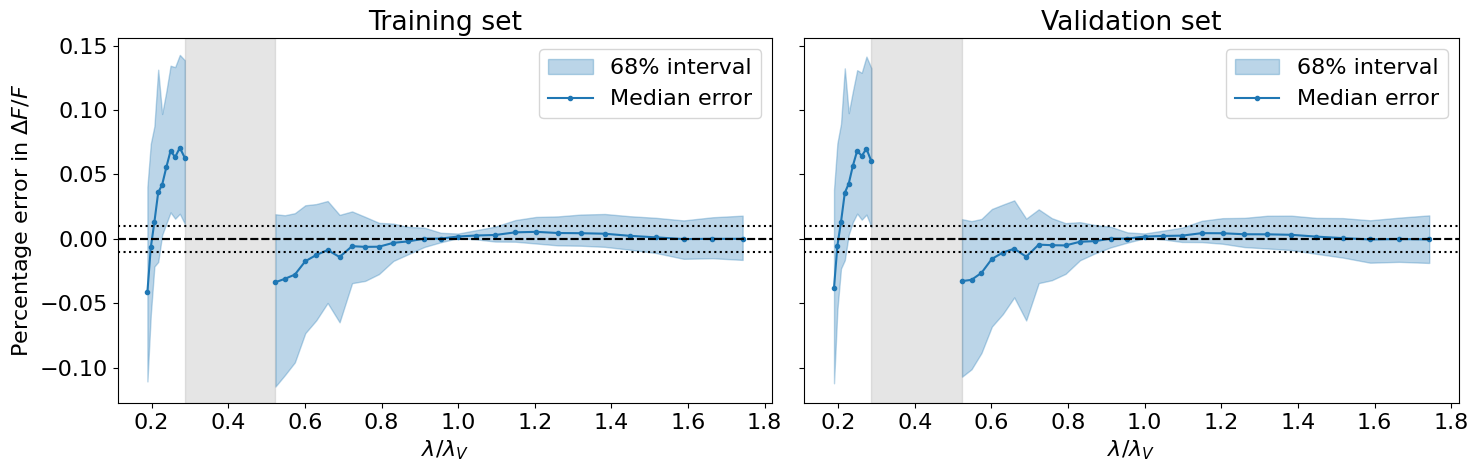

In [51]:
def compute_initial_C(IOB):
    c = [0.908373, 0.748169, 0.944124, 59.20784, 5.327414, 0.010842]
    B0 = c[0]*np.log(IOB[0]*c[3] + c[4])
    C0 = B0 * np.log(10)
    return C0

def compute_Av(x, b, C0):
    A_over_Av = b[0] * np.exp(C0*(np.tanh(b[1]) - np.tanh(b[1]*x)))
    return A_over_Av

def loss_fun_b(b, x, A_true, A_v, C0):
    A_pred = compute_Av(x, b, C0)
    # loss = np.sqrt(np.mean((np.log(ypred) - np.log(ytrue))**2))
    dF_F_train = 10. ** (0.4 * A_v * (A_true - A_pred)) - 1.0
    loss = np.sqrt(np.mean(dF_F_train**2))
    return loss

b_init = [10 ** (-0.0108420000000000), 0.944124]

args = OperonArgs(ini_file)

# Load training and validation data
dirname = pjoin(args.out_data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')
df_train = pd.read_csv(fname_train, sep=r'\s+')
df_val = pd.read_csv(fname_val, sep=r'\s+')

# Get the normalisation of the curves
df_all_train = pd.read_csv(args.selection.train_file)
df_all_val = pd.read_csv(args.selection.val_file)
log_Av_col = f'logA_{int(args.lambda_V*1e4)}A'
A_v_col = f'A_{int(args.lambda_V*1e4)}A'
if log_Av_col in df_all_train.columns:
    lv_key = log_Av_col
elif A_v_col in df_all_train.columns:
    lv_key = A_v_col
else:
    raise ValueError("Column with lambda_V not found in input file")

# Get A_v for training and validation sets so we can calculate dF/F after fitting
train_id = df_train['galaxy_id'].values
train_los = df_train['los'].values
val_id = df_val['galaxy_id'].values
val_los = df_val['los'].values
m = df_all_train.set_index(['galaxy_id', 'los'])
train_Av = m.loc[list(zip(train_id, train_los)), lv_key].values
m = df_all_val.set_index(['galaxy_id', 'los'])
val_Av = m.loc[list(zip(val_id, val_los)), lv_key].values

print(df_train.shape, train_Av.shape)

# Extract IOB values and variables we care about
IOB_cols = sorted([col for col in df_train.columns if re.match(r'IOB\d+', col)])
IOB_train = df_train[IOB_cols].values
IOB_val = df_val[IOB_cols].values
x_train = df_train['lam'].values
x_val = df_val['lam'].values

# Get C0 for training and validation sets
C0_train = compute_initial_C(IOB_train.T)
C0_val = compute_initial_C(IOB_val.T)

A_train = df_train['A'].values
A_val = df_val['A'].values

print(f'\nInitial b parameters: {b_init}')
print(f'Training loss with initial b: {loss_fun_b(b_init, x_train, A_train, train_Av, C0_train)}')
print(f'Validation loss with initial b: {loss_fun_b(b_init, x_val, A_val, val_Av, C0_val)}')

# Optimise b parameters
res = scipy.optimize.minimize(loss_fun_b, b_init, args=(x_train, A_train, train_Av, C0_train), method='Nelder-Mead')
print(f'\n{res.success}, {res.message}\n')
b_opt = res.x

print(f'Optimised b parameters: {b_opt}')
print(f'Training loss with optimised b: {loss_fun_b(b_opt, x_train, A_train, train_Av, C0_train)}')
print(f'Validation loss with optimised b: {loss_fun_b(b_opt, x_val, A_val, val_Av, C0_val)}')

# Obtain percentiles of errors on training set at fixed x values
# Get median and 68% intervals
x_uniq = np.unique(x_train)
dF_errs_train = np.zeros((len(x_uniq), 3))
dF_errs_val = np.zeros((len(x_uniq), 3))
for i, xval in enumerate(x_uniq):

    indices = np.where(x_train == xval)[0]
    A_true_x = A_train[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_train[indices])
    dF_F = 10. ** (0.4 * train_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_train[i,0] = np.percentile(dF_F, 16.)
    dF_errs_train[i,1] = np.percentile(dF_F, 50.)
    dF_errs_train[i,2] = np.percentile(dF_F, 84.)

    indices = np.where(x_val == xval)[0]
    A_true_x = A_val[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_val[indices])
    dF_F = 10. ** (0.4 * val_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_val[i,0] = np.percentile(dF_F, 16.)
    dF_errs_val[i,1] = np.percentile(dF_F, 50.)
    dF_errs_val[i,2] = np.percentile(dF_F, 84.)

mlow = x_uniq <= args.lam_bump_min / args.lambda_V
mhigh = x_uniq >= args.lam_bump_max / args.lambda_V

fig, axs = plt.subplots(1, 2, figsize=(15,5), sharey=True)
axs[0].fill_between(x_uniq[mlow], dF_errs_train[mlow,0], dF_errs_train[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[0].fill_between(x_uniq[mhigh], dF_errs_train[mhigh,0], dF_errs_train[mhigh,2], color='C0', alpha=0.3)
axs[0].plot(x_uniq[mlow], dF_errs_train[mlow,1], marker='.', label='Median error', color='C0')
axs[0].plot(x_uniq[mhigh], dF_errs_train[mhigh,1], marker='.', color='C0')
axs[0].axhline(0., color='k', ls='--')
axs[0].set_xlabel(r'$\lambda / \lambda_V$')
axs[0].set_ylabel(r'Percentage error in $\Delta F / F$')
axs[0].legend()
axs[1].fill_between(x_uniq[mlow], dF_errs_val[mlow,0], dF_errs_val[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[1].fill_between(x_uniq[mhigh], dF_errs_val[mhigh,0], dF_errs_val[mhigh,2], color='C0', alpha=0.3)
axs[1].plot(x_uniq[mlow], dF_errs_val[mlow,1], marker='.', label='Median error', color='C0')
axs[1].plot(x_uniq[mhigh], dF_errs_val[mhigh,1], marker='.', color='C0')
axs[1].axhline(0., color='k', ls='--')
axs[1].set_xlabel(r'$\lambda / \lambda_V$')
axs[1].legend()
axs[0].set_title('Training set')
axs[1].set_title('Validation set')
for ax in axs:
    ax.axhline(0., color='k', ls='--')
    ax.axhline(0.01, color='k', ls=':')
    ax.axhline(-0.01, color='k', ls=':')
    xlow = max(x_uniq[mlow])
    xhigh = min(x_uniq[mhigh])
    ylim = ax.get_ylim()
    ax.fill_betweenx(ax.get_ylim(), xlow, xhigh, color='grey', alpha=0.2)
    ax.set_ylim(ylim)
fig.tight_layout()

After fixing the $b$ parameters, we re-optimised the C0. Compare the losses for each gal and the values of C0

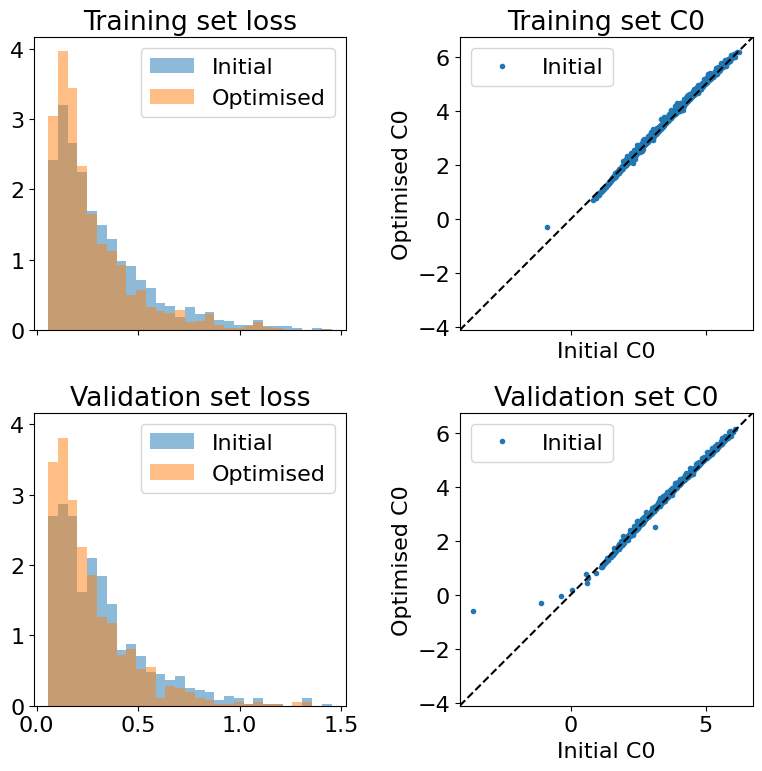

In [71]:
fname_train = '/mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/outer_fit_results_train.csv'
df_results_train = pd.read_csv(fname_train)
fname_val = '/mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/outer_fit_results_val.csv'
df_results_val = pd.read_csv(fname_val)

fig, axs = plt.subplots(2, 2, figsize=(8,8), sharey='col', sharex='col')

bins = np.linspace(np.percentile(df_results_train['loss_init'], 0.5), np.percentile(df_results_train['loss_init'], 99.5), 30)
axs[0,0].hist(df_results_train['loss_init'], bins=bins, density=True, alpha=0.5, label='Initial')
axs[0,0].hist(df_results_train['loss_opt'], bins=bins, density=True, alpha=0.5, label='Optimised')
axs[1,0].hist(df_results_val['loss_init'], bins=bins, density=True, alpha=0.5, label='Initial')
axs[1,0].hist(df_results_val['loss_opt'], bins=bins, density=True, alpha=0.5, label='Optimised')

axs[0,1].plot(df_results_train['C0_init'], df_results_train['C0_opt'], '.', label='Initial')
axs[1,1].plot(df_results_val['C0_init'], df_results_val['C0_opt'], '.', label='Initial')
for ax in axs[:,1]:
    ax.set_xlabel('Initial C0')
    ax.set_ylabel('Optimised C0')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xlim = (min(xlim[0], ylim[0]), max(xlim[1], ylim[1]))
    ylim = xlim
    ax.plot(xlim, ylim, 'k--')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal', 'box')
for ax in axs.flatten():
    ax.legend()
axs[0,0].set_title('Training set loss')
axs[1,0].set_title('Validation set loss')
axs[0,1].set_title('Training set C0')
axs[1,1].set_title('Validation set C0')
fig.tight_layout()

Now see how this looks in terms of the attenuation curve

(54501,) (27232,)


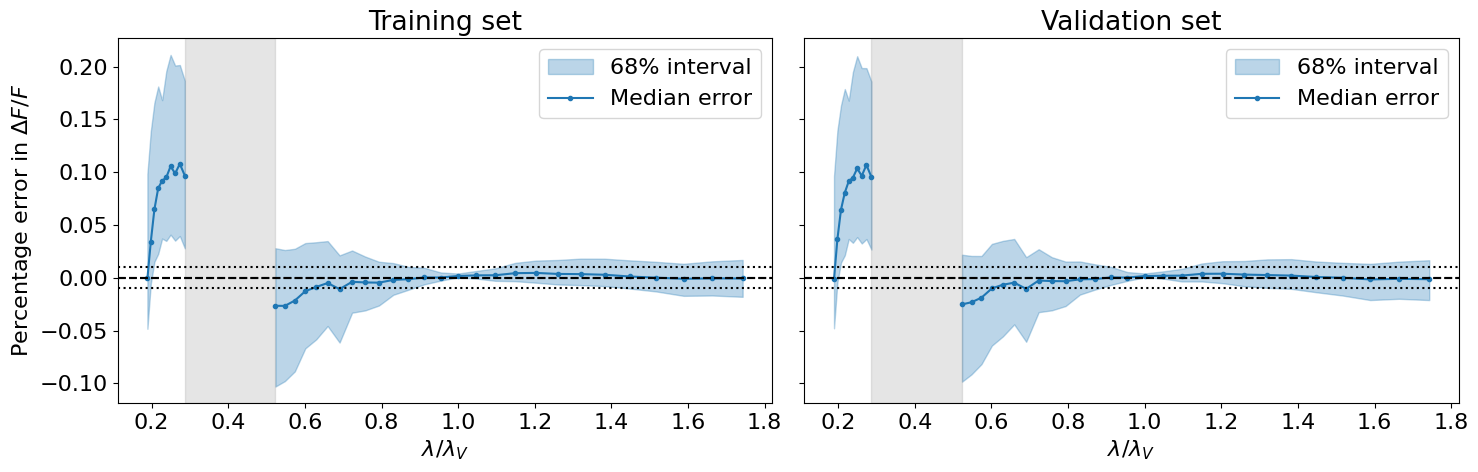

In [80]:
C0_train = df_results_train['C0_opt'].values
C0_val = df_results_val['C0_opt'].values

# Repeat this value so that this has the same shape as our training data
C0_train_full = np.repeat(C0_train, len(x_uniq))
C0_val_full = np.repeat(C0_val, len(x_uniq))
print(C0_train_full.shape, C0_val_full.shape)

# Obtain percentiles of errors on training set at fixed x values
# Get median and 68% intervals
x_uniq = np.unique(x_train)
dF_errs_train = np.zeros((len(x_uniq), 3))
dF_errs_val = np.zeros((len(x_uniq), 3))
for i, xval in enumerate(x_uniq):

    indices = np.where(x_train == xval)[0]
    A_true_x = A_train[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_train_full[indices])
    dF_F = 10. ** (0.4 * train_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_train[i,0] = np.percentile(dF_F, 16.)
    dF_errs_train[i,1] = np.percentile(dF_F, 50.)
    dF_errs_train[i,2] = np.percentile(dF_F, 84.)

    indices = np.where(x_val == xval)[0]
    A_true_x = A_val[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_val_full[indices])
    dF_F = 10. ** (0.4 * val_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_val[i,0] = np.percentile(dF_F, 16.)
    dF_errs_val[i,1] = np.percentile(dF_F, 50.)
    dF_errs_val[i,2] = np.percentile(dF_F, 84.)
    
mlow = x_uniq <= args.lam_bump_min / args.lambda_V
mhigh = x_uniq >= args.lam_bump_max / args.lambda_V

fig, axs = plt.subplots(1, 2, figsize=(15,5), sharey=True)
axs[0].fill_between(x_uniq[mlow], dF_errs_train[mlow,0], dF_errs_train[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[0].fill_between(x_uniq[mhigh], dF_errs_train[mhigh,0], dF_errs_train[mhigh,2], color='C0', alpha=0.3)
axs[0].plot(x_uniq[mlow], dF_errs_train[mlow,1], marker='.', label='Median error', color='C0')
axs[0].plot(x_uniq[mhigh], dF_errs_train[mhigh,1], marker='.', color='C0')
axs[0].axhline(0., color='k', ls='--')
axs[0].set_xlabel(r'$\lambda / \lambda_V$')
axs[0].set_ylabel(r'Percentage error in $\Delta F / F$')
axs[0].legend()
axs[1].fill_between(x_uniq[mlow], dF_errs_val[mlow,0], dF_errs_val[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[1].fill_between(x_uniq[mhigh], dF_errs_val[mhigh,0], dF_errs_val[mhigh,2], color='C0', alpha=0.3)
axs[1].plot(x_uniq[mlow], dF_errs_val[mlow,1], marker='.', label='Median error', color='C0')
axs[1].plot(x_uniq[mhigh], dF_errs_val[mhigh,1], marker='.', color='C0')
axs[1].axhline(0., color='k', ls='--')
axs[1].set_xlabel(r'$\lambda / \lambda_V$')
axs[1].legend()
axs[0].set_title('Training set')
axs[1].set_title('Validation set')
for ax in axs:
    ax.axhline(0., color='k', ls='--')
    ax.axhline(0.01, color='k', ls=':')
    ax.axhline(-0.01, color='k', ls=':')
    xlow = max(x_uniq[mlow])
    xhigh = min(x_uniq[mhigh])
    ylim = ax.get_ylim()
    ax.fill_betweenx(ax.get_ylim(), xlow, xhigh, color='grey', alpha=0.2)
    ax.set_ylim(ylim)
fig.tight_layout()

# Investigate terms in the "inner" function


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini
['IOB1', 'IOB2', 'IOB3', 'IOB4', 'IOB5', 'IOB6', 'IOB7', 'IOB8']
x1: 0.21615371300410585
x2 min: 0.0035690625326632234, x2 max: 20.798092391035045
Number of positive x2: 1408, number of negative x2: 65
Fraction positive: 0.9559
Fraction negative: 0.0441
Number of 0.1 < x2 < 1.0: 1338
Fraction 0.1 < x2 < 1.0: 0.9084
Number of positive D1: 1364, number of negative D1: 109
Fraction positive: 0.9260
Fraction negative: 0.0740
b2 45.149438890248


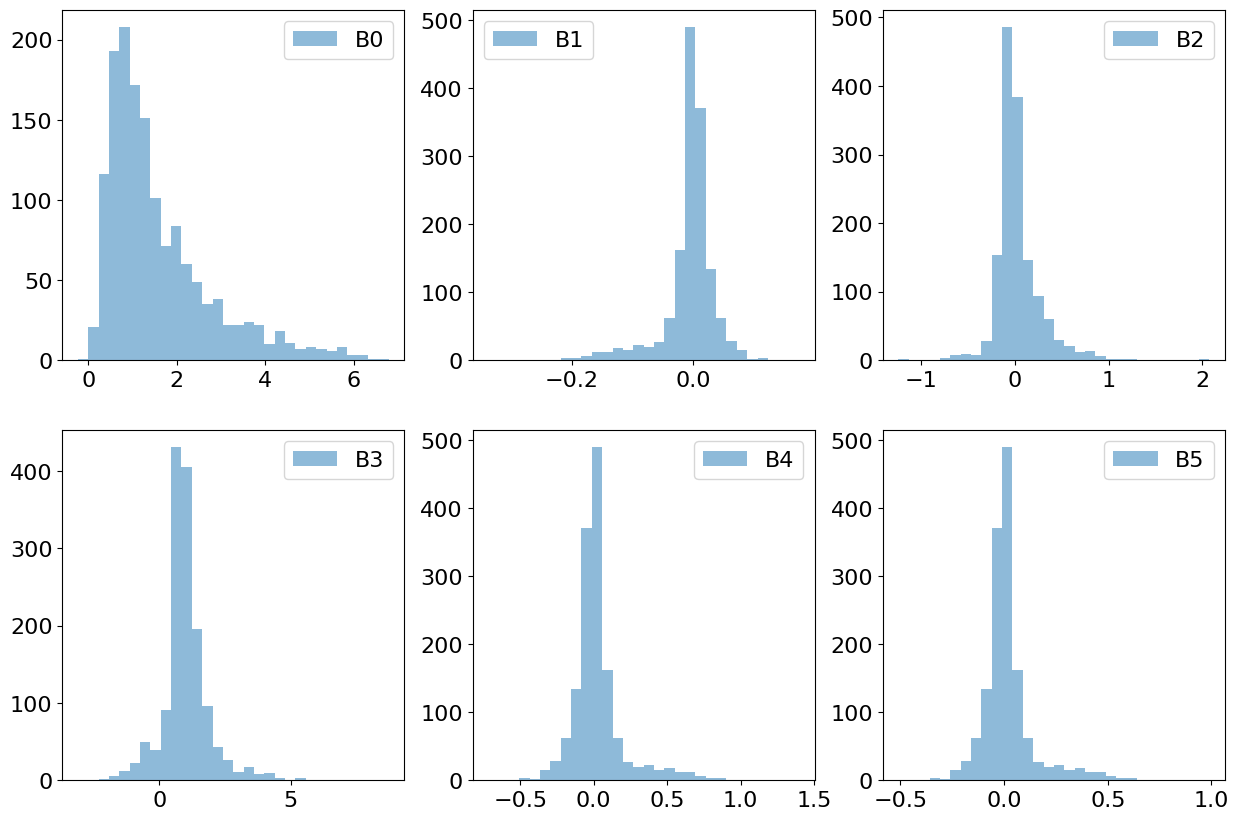

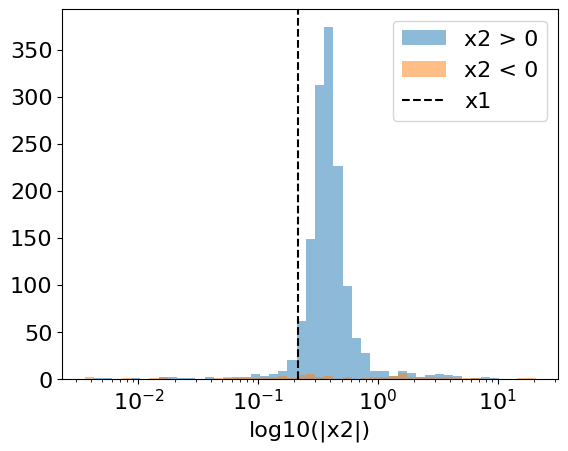

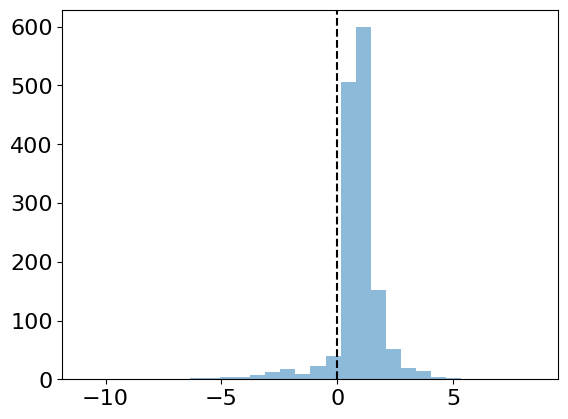

In [46]:
name = 'train'
ini_file = 'conf/iob_44.ini'; ilen = 43

args = OperonArgs(ini_file)

fname = args.selection.train_file if name == 'train' else args.selection.val_file
data_train = pd.read_csv(fname)
iob_cols = sorted([col for col in data_train.columns if re.match(r'IOB\d+', col)])

c = [1.000648, 45.120201, 208.741272, 2.214609, 11.210193, 1.380509, 22.421267, 5.736165, 3.953059, 5.040799, 7.073277, 3.570695, 9.125808, 1.000648, 21.685377, 1.474194, 1.215716, 16.786709, 6.730947, 0.002466]

print(iob_cols)
# {B0: c13*(IOB1*c14 + c15), B1: IOB2*c16, B2: IOB1*c3 - IOB3*c4, B3: (IOB2*c6 + exp(IOB1*c7))*exp(-IOB3*c10), B4: -IOB2*c9, B5: -IOB2*c11}
B0 = c[13] * (data_train['IOB1'].values * c[14] + c[15])
B1 = data_train['IOB2'].values * c[16]
B2 = c[3] * data_train['IOB1'].values - c[4] * data_train['IOB3'].values
B3 = (c[6] * data_train['IOB2'].values + np.exp(c[7] * data_train['IOB1'].values)) * np.exp(-c[10] * data_train['IOB3'].values)
B4 = -c[9] * data_train['IOB2'].values
B5 = -c[11] * data_train['IOB2'].values

fig, axs = plt.subplots(2, 3, figsize=(15,10))
axs[0,0].hist(B0, bins=30, alpha=0.5, label='B0')
axs[0,1].hist(B1, bins=30, alpha=0.5, label='B1')
axs[0,2].hist(B2, bins=30, alpha=0.5, label='B2')
axs[1,0].hist(B3, bins=30, alpha=0.5, label='B3')
axs[1,1].hist(B4, bins=30, alpha=0.5, label='B4')
axs[1,2].hist(B5, bins=30, alpha=0.5, label='B5')
for ax in axs.flatten():
    ax.legend()

a = [-0.00246600000000000, -9.12580800000000, 45.120201, 1.380509, -6.73094700000000, 16.786709, 1.000648, -208.741272000000, -3.95305900000000]

x1 = - a[2] / a[7]
print(f'x1: {x1}')

# x2 = - 1/a[8] * (np.exp(B4) + B2 / B3)
x2 = - (B2 + B3 * np.exp(B4)) / (a[8] * B3 + a[3])
xmin = np.min(np.abs(x2))
xmax = np.max(np.abs(x2))
bins = np.logspace(np.log10(xmin), np.log10(xmax), 50)
print(f'x2 min: {xmin}, x2 max: {xmax}')
plt.figure()
plt.hist(x2[x2>0], bins=bins, alpha=0.5, label='x2 > 0')
plt.hist(-x2[x2<0], bins=bins, alpha=0.5, label='x2 < 0')
plt.axvline(x1, color='k', ls='--', label='x1')
plt.xscale('log')
plt.xlabel('log10(|x2|)')
plt.legend()

npos = np.sum(x2 > 0)
nneg = np.sum(x2 < 0)
print(f'Number of positive x2: {npos}, number of negative x2: {nneg}')
print(f'Fraction positive: {npos / (npos + nneg):.4f}')
print(f'Fraction negative: {nneg / (npos + nneg):.4f}')

m = (x2 > 0.1) & (x2 < 1.0)
print(f'Number of 0.1 < x2 < 1.0: {np.sum(m)}')
print(f'Fraction 0.1 < x2 < 1.0: {np.sum(m) / (npos + nneg):.4f}')

D1 = np.exp(B5) * (B2 + B3 * np.exp(B4))
npos = np.sum(D1 > 0)
nneg = np.sum(D1 < 0)
print(f'Number of positive D1: {npos}, number of negative D1: {nneg}')
print(f'Fraction positive: {npos / (npos + nneg):.4f}')
print(f'Fraction negative: {nneg / (npos + nneg):.4f}')
plt.figure()
plt.hist(D1, bins=30, alpha=0.5)
plt.axvline(0., color='k', ls='--')

print('b2', a[2] * a[6])


# Test Full Function


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini
[   1.01563835   -9.22294807   44.51240158 -212.77281189    0.40022305
  285.62985229]
(1473, 71) (1473,) (1473,)
Initial RMSE: 0.027534533022115712

True, Optimization terminated successfully.

Optimised D: [ 1.4365586   0.74200385 -0.69086242  3.07549482]
Optimised RMSE: 0.003914875724624128
2-param fit success: True, popt: [ 3.64272782 -0.41926972]
4-param fit success: True, popt: [ 6.74838254  1.79788838 -0.74326932  0.07549851]


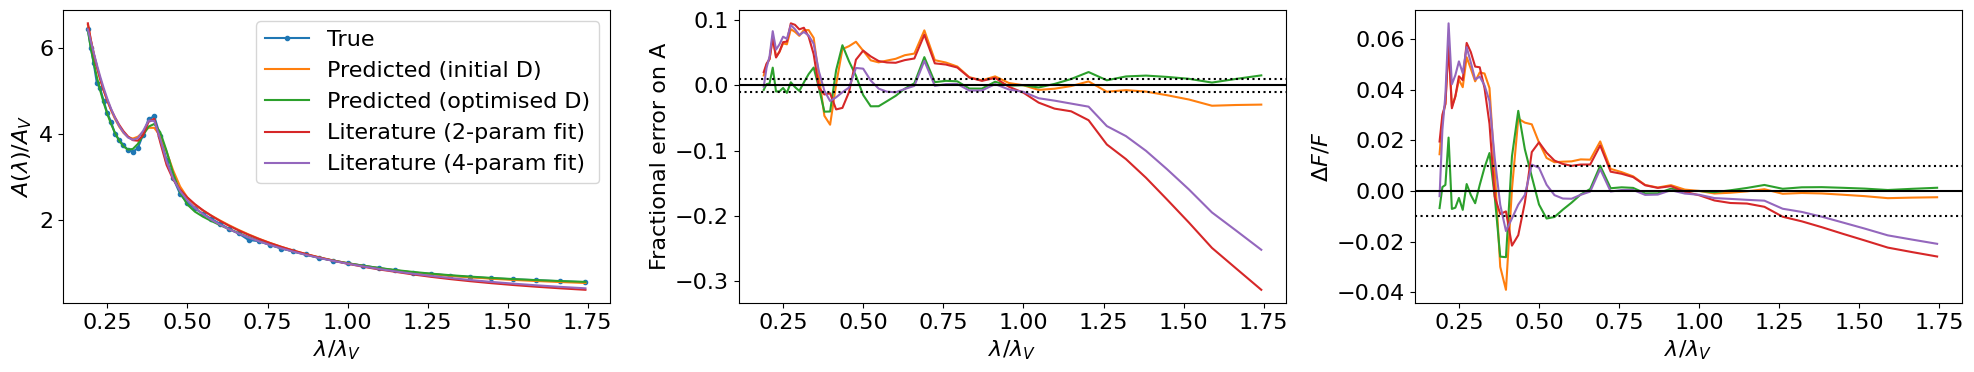

In [113]:
name = 'train'
ini_file = 'conf/iob_44.ini'; ilen = 43

args = OperonArgs(ini_file)

fname = args.selection.train_file if name == 'train' else args.selection.val_file
fname_outer = f'{args.fit_dir}/{run_name}/{run_name}_outer_{name}.csv'

df_orig = pd.read_csv(fname)

# Load data with C0
run_name = f'{args.in_param}_{str(args.version_num)}'
df_outer = pd.read_csv(fname_outer)
nx = len(set(df_outer['x'].values))
assert int(df_outer.shape[0] / nx) == df_orig.shape[0]
C0 = df_outer['C0'].values[::nx]

# Get initial D values
# {B0: c13*(IOB1*c14 + c15), B1: IOB2*c16, B2: IOB1*c3 - IOB3*c4, B3: (IOB2*c6 + exp(IOB1*c7))*exp(-IOB3*c10), B4: -IOB2*c9, B5: -IOB2*c11}
c = [1.000648, 45.120201, 208.741272, 2.214609, 11.210193, 1.380509, 22.421267, 5.736165, 3.953059, 5.040799, 7.073277, 3.570695, 9.125808, 1.000648, 21.685377, 1.474194, 1.215716, 16.786709, 6.730947, 0.002466]
a = [-0.00246600000000000, -9.12580800000000, 45.120201, 1.380509, -6.73094700000000, 16.786709, 1.000648, -208.741272000000, -3.95305900000000]
B0 = c[13] * (df_orig['IOB1'].values * c[14] + c[15])
B1 = df_orig['IOB2'].values * c[16]
B2 = c[3] * df_orig['IOB1'].values - c[4] * df_orig['IOB3'].values
B3 = (c[6] * df_orig['IOB2'].values + np.exp(c[7] * df_orig['IOB1'].values)) * np.exp(-c[10] * df_orig['IOB3'].values)
B4 = -c[9] * df_orig['IOB2'].values
B5 = -c[11] * df_orig['IOB2'].values
D0 = B0 * np.exp(B1)
D1 = np.exp(B5) * (B2 + B3 * np.exp(B4))
D2 = (a[8] * B3 + a[3]) * np.exp(B5)

# Get initial b values
b = np.zeros(6)
b[0] = 0.944124
b[1] = a[1]
b[2] = a[2] * a[6]
b[3] = a[6] * a[7]
b[4] = - a[4] / a[5]
b[5] = a[5] ** 2

# Use optimised b values from elsewhere
b = [0.94419646, -9.234771, 45.6097, -209.46132, 0.39963165, 283.04437]
b = np.loadtxt('opt_fun_final_b_params.txt')
print(b)

# Get the true data
attenuation_cols = [col for col in df_orig.columns if re.match(r'A_\d+A', col)]
lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
sort_idx = np.argsort(lam_arr)
lam_arr = lam_arr[sort_idx]
mask = (lam_arr < args.lam_max) & (lam_arr > args.lam_min)
lam_arr = lam_arr[mask]
attenuation_cols = [attenuation_cols[i] for i in sort_idx if mask[i]]
A_v_col = f'A_{int(args.lambda_V*1e4)}A'
x = lam_arr / args.lambda_V
nlam = len(x)
curves_flat = df_orig[attenuation_cols].values
ytrue = curves_flat / df_orig[A_v_col].values[:,None]

def get_ypred(x, D0, D1, D2, D3):
    y = (
        D0 * (np.exp(-b[5] * (x - b[4])**2) - np.exp(-b[5] * (1. - b[4])**2))
        + (b[2] + b[3] * x) * (D1 + D2 * x) * (np.exp(b[1] * x) - np.exp(b[1]))
        + np.exp(D3 * (np.tanh(b[0]) - np.tanh(b[0] * x)))
    )
    return y

print(df_orig.shape, C0.shape, D0.shape)

# Example galaxy
igal = 1 # 1 is a good example
igal = 100

gal_ytrue = ytrue[igal,:]
gal_D0 = D0[igal]
gal_D1 = D1[igal]
gal_D2 = D2[igal]
gal_D3 = C0[igal]
gal_ypred = get_ypred(x, gal_D0, gal_D1, gal_D2, gal_D3)

def to_opt(D):
    ypred = get_ypred(x, D[0], D[1], D[2], D[3])
    ytrue = gal_ytrue
    mse = np.mean((ypred - ytrue)**2)
    # dF_F_ = 10. ** (0.4 * df_orig[A_v_col].values[igal] * (ypred - ytrue)) - 1.0
    # rmse = np.sqrt(np.mean(dF_F_**2))
    return mse

D_init = np.array([gal_D0, gal_D1, gal_D2, gal_D3])
print(f'Initial RMSE: {to_opt(D_init)}')
res = scipy.optimize.minimize(to_opt, D_init, method='Nelder-Mead')
print(f'\n{res.success}, {res.message}\n')
D_opt = res.x
print(f'Optimised D: {D_opt}')
print(f'Optimised RMSE: {to_opt(D_opt)}')
ypred_opt = get_ypred(x, D_opt[0], D_opt[1], D_opt[2], D_opt[3])

# Run 2-parameter fit from literature
popt_2par, success_2par = fit_literature.run_fit(attenuation_curves.Att_Curve_2param, 
                            1e4*lam_arr, gal_ypred, 
                            bounds = ([-np.inf,-np.inf],[np.inf,np.inf]))
ypred_2par = attenuation_curves.Att_Curve_2param(1e4*lam_arr, *popt_2par)
print(f'2-param fit success: {success_2par}, popt: {popt_2par}')

# Run 4-parameter fit from literature
# Initial guesses for 4-parameter fit
all_p0_4par = [
    [44.9, 7.56, 61.2, 0.],  # 'Calzetti'
    [38.7, 3.83, 6.34, 0.], #'SMC'
    [14.4, 6.52, 2.04, 0.0519], # 'MW'
    [4.47, 2.39, -0.988, 0.0221], # 'LMC'
    [1.0, 1.0, 1.0, 1.0],  # Generic initial guess
]
opt_4par, success_4par = fit_literature.run_fit(attenuation_curves.Li_08_fit_noratio, 
                            lam_arr, gal_ypred, 
                            bounds=([-np.inf,-np.inf,-np.inf,0],[np.inf,np.inf,np.inf,1.]),
                            all_p0=all_p0_4par)
ypred_4par = attenuation_curves.Li_08_fit_noratio(lam_arr, *opt_4par)
print(f'4-param fit success: {success_4par}, popt: {opt_4par}')

# dF_F = 10. ** (0.4 * A_star * (t - p)) - 1.0
dF_F = 10. ** (0.4 * df_orig[A_v_col].values[igal] * (gal_ypred - gal_ytrue)) - 1.0
dF_F_opt = 10. ** (0.4 * df_orig[A_v_col].values[igal] * (ypred_opt - gal_ytrue)) - 1.0
dF_F_2par = 10. ** (0.4 * df_orig[A_v_col].values[igal] * (ypred_2par - gal_ytrue)) - 1.0
dF_F_4par = 10. ** (0.4 * df_orig[A_v_col].values[igal] * (ypred_4par - gal_ytrue)) - 1.0

fig, axs = plt.subplots(1, 3, figsize=(20,4))
axs[0].plot(x, gal_ytrue, label='True', marker='.')
axs[0].plot(x, gal_ypred, label='Predicted (initial D)')
axs[0].plot(x, ypred_opt, label='Predicted (optimised D)')
axs[0].plot(x, ypred_2par, label='Literature (2-param fit)')
axs[0].plot(x, ypred_4par, label='Literature (4-param fit)')
axs[0].legend()
axs[0].set_ylabel(r'$A(\lambda) / A_V$')
axs[1].plot(x, gal_ypred / gal_ytrue - 1, color='C1')
axs[1].plot(x, ypred_opt / gal_ytrue - 1, color='C2')
axs[1].plot(x, ypred_2par / gal_ytrue - 1, color='C3')
axs[1].plot(x, ypred_4par / gal_ytrue - 1, color='C4')
axs[1].set_ylabel('Fractional error on A')
axs[2].plot(x, dF_F, color='C1')
axs[2].plot(x, dF_F_opt, color='C2')
axs[2].plot(x, dF_F_2par, color='C3')
axs[2].plot(x, dF_F_4par, color='C4')
axs[2].set_ylabel(r'$\Delta F / F$')

ylim = axs[2].get_ylim()
ylim = (max(ylim[0], -0.1), min(ylim[1], 0.1))
axs[2].set_ylim(ylim)

for ax in axs[1:]:
    ax.axhline(0., color='k', ls='-')
    ax.axhline(0.01, color='k', ls=':')
    ax.axhline(-0.01, color='k', ls=':')

for ax in axs:
    ax.set_xlabel(r'$\lambda / \lambda_V$')

fig.tight_layout()

# All results from fitting curves


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/train_data_v1.csv with 1473 galaxies.



Calculating fits for train set: 100%|██████████| 1473/1473 [00:00<00:00, 2210.99it/s]



Mean absolute errors for train set:
	2-parameter fit: 0.0742
	4-parameter fit: 0.0545
	New model fit: 0.0323

Mean absolute dF/F errors for train set:
	2-parameter fit: 0.0272
	4-parameter fit: 0.0188
	New model fit: 0.0107
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/val_data_v1.csv with 736 galaxies.



Calculating fits for val set: 100%|██████████| 736/736 [00:00<00:00, 2210.44it/s]



Mean absolute errors for val set:
	2-parameter fit: 0.0739
	4-parameter fit: 0.0557
	New model fit: 0.0334

Mean absolute dF/F errors for val set:
	2-parameter fit: 0.0268
	4-parameter fit: 0.0183
	New model fit: 0.0102


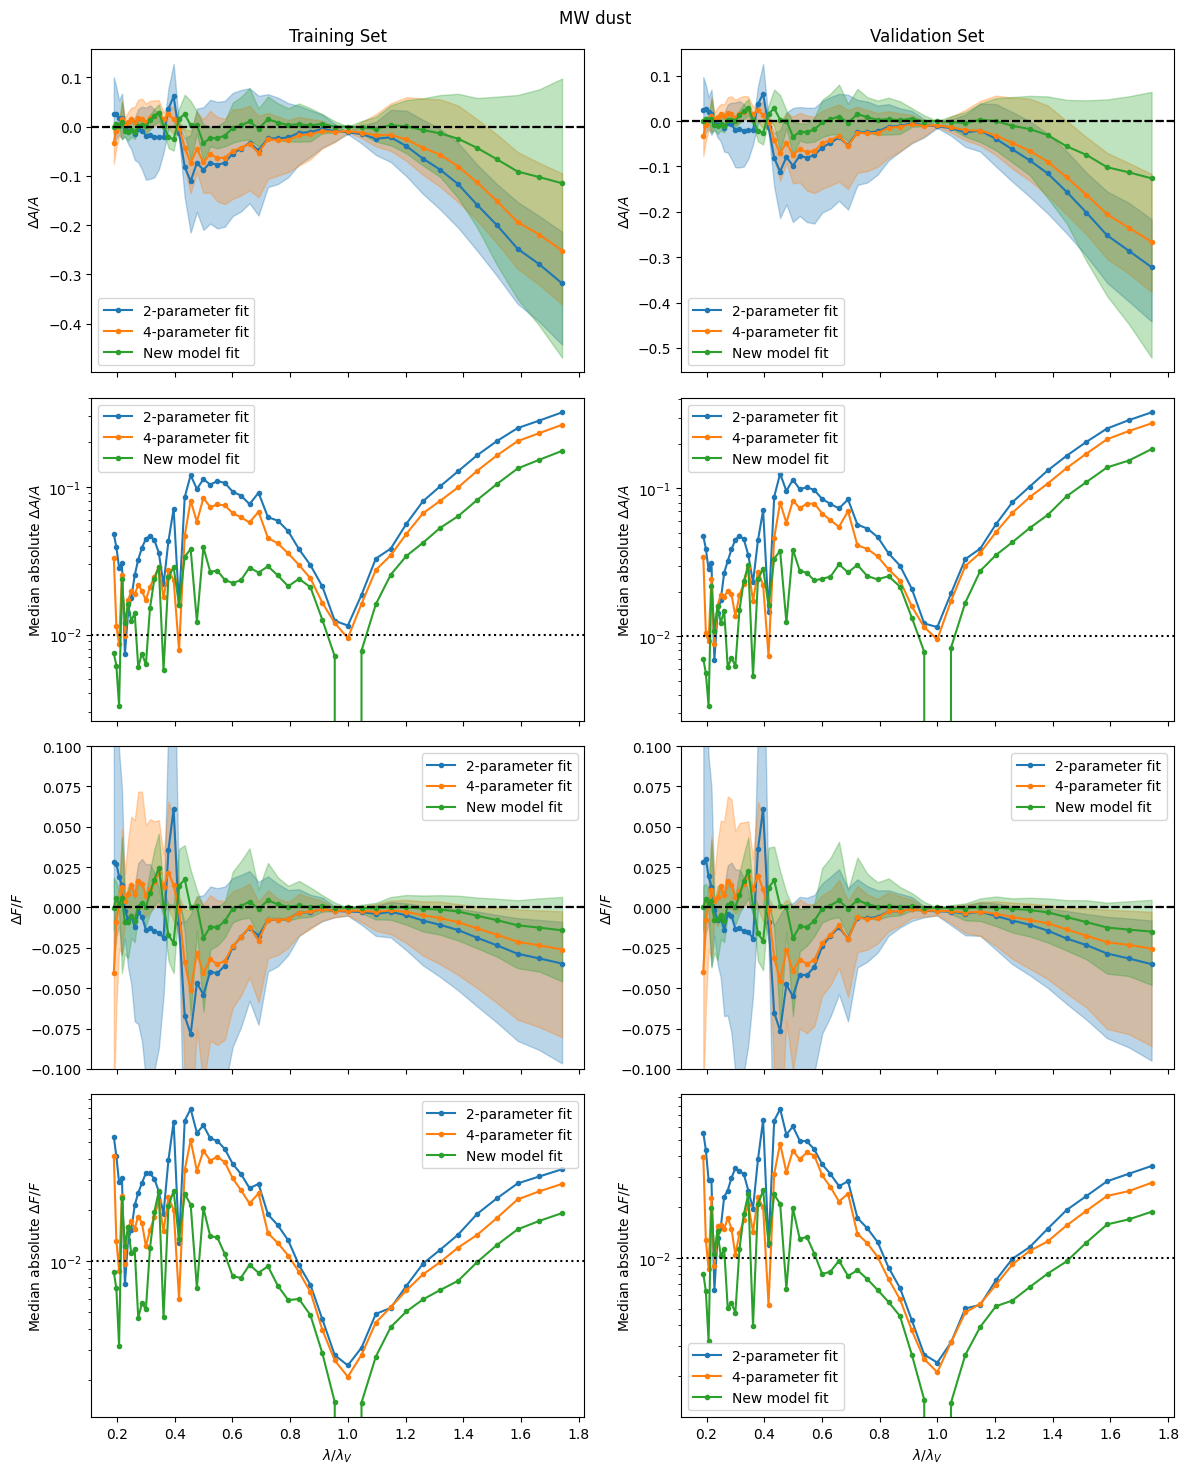

In [16]:
ini_file = 'conf/iob_44.ini' # MW

args = OperonArgs(ini_file)

# lam_min = 0.12
# lam_max = 1.0
lam_min = args.lam_min 
lam_max = args.lam_max

fig, axs = plt.subplots(4, 2, figsize=(12,15), sharex=True)

# for name in ['train', 'val']:
for j, name in enumerate(['train', 'val']):

    x, ytrue, _, _, _, Av = fit_curves.load_data(args, name)
    run_name = f'{args.in_param}_{str(args.version_num)}'
    fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
    df_opt = pd.read_csv(fname_opt)
    lam = x * args.lambda_V

    m = (lam >= lam_min) & (lam <= lam_max)
    # m = np.ones_like(lam, dtype=bool)
    x = x[m]
    lam = lam[m]
    ytrue = ytrue[:,m]

    ypred_2par = np.zeros_like(ytrue)
    ypred_4par = np.zeros_like(ytrue)
    ypred_new = np.zeros_like(ytrue)

    popt_4par = df_opt[['4par_p0', '4par_p1', '4par_p2', '4par_p3']].values
    popt_2par = df_opt[['2par_B', '2par_delta']].values
    # popt_new = df_opt[['newpar_D0', 'newpar_D1', 'newpar_D2', 'newpar_D3']].values
    popt_new = df_opt[['newpar_reparam_A0', 'newpar_reparam_A1', 'newpar_reparam_A2', 'newpar_reparam_A3']].values
     
    # Get predicted curves for each galaxy
    print('')
    for i in tqdm(range(len(ytrue)), desc=f'Calculating fits for {name} set'):
        ypred_2par[i,:] = attenuation_curves.Att_Curve_2param(1e4*lam, *popt_2par[i,:])
        ypred_4par[i,:] = attenuation_curves.Li_08_fit_noratio(lam, *popt_4par[i,:])
        # ypred_new[i,:] = fit_curves.new_model(x, *popt_new[i,:])
        ypred_new[i,:] = fit_curves.new_model_reparam(x, *popt_new[i,:])

    # Calculate fractional errors on A
    frac_err_2par = (ypred_2par - ytrue) / ytrue
    frac_err_4par = (ypred_4par - ytrue) / ytrue
    frac_err_new = (ypred_new - ytrue) / ytrue

    # Calculate dF/F errors
    # dF_F = 10. ** (0.4 * A_v * (A_pred - A_true)) - 1.0
    dF_F_2par = 10. ** (0.4 * Av[:,None] * (ypred_2par - ytrue)) - 1.0
    dF_F_4par = 10. ** (0.4 * Av[:,None] * (ypred_4par - ytrue)) - 1.0
    dF_F_new = 10. ** (0.4 * Av[:,None] * (ypred_new - ytrue)) - 1.0

    for i, (errs, title) in enumerate(zip([frac_err_2par, frac_err_4par, frac_err_new],
                                          ['2-parameter fit', '4-parameter fit', 'New model fit'])):
        ax = axs[0,j]
        median_err = np.median(errs, axis=0)
        p16 = np.percentile(errs, 16., axis=0)
        p84 = np.percentile(errs, 84., axis=0)
        ax.fill_between(x, p16, p84, color=f'C{i}', alpha=0.3)
        ax.plot(x, median_err, marker='.', label=title, color=f'C{i}')
        ax.axhline(0., color='k', ls='--')
        if i == 0:
            ax.set_ylabel(r"$\Delta A / A$")
        ax.legend()

        ax = axs[1,j]
        median_abs_err = np.median(np.abs(errs), axis=0)
        ax.plot(x, median_abs_err, marker='.', label=title, color=f'C{i}')
        if i == 0:
            ax.set_ylabel('Median absolute ' + r"$\Delta A / A$")
        ax.legend()

    for i, (errs, title) in enumerate(zip([dF_F_2par, dF_F_4par, dF_F_new],
                                          ['2-parameter fit', '4-parameter fit', 'New model fit'])):
        ax = axs[2,j]
        median_err = np.median(errs, axis=0)
        p16 = np.percentile(errs, 16., axis=0)
        p84 = np.percentile(errs, 84., axis=0)
        ax.fill_between(x, p16, p84, color=f'C{i}', alpha=0.3)
        ax.plot(x, median_err, marker='.', label=title, color=f'C{i}')
        ax.axhline(0., color='k', ls='--')
        if i == 0:
            ax.set_ylabel(r'$\Delta F / F$')
        ax.legend()
        
        ax = axs[3,j]
        median_abs_err = np.median(np.abs(errs), axis=0)
        ax.plot(x, median_abs_err, marker='.', label=title, color=f'C{i}')
        ax.set_xlabel(r'$\lambda / \lambda_V$')
        if i == 0:
            ax.set_ylabel('Median absolute ' + r'$\Delta F / F$')
        ax.legend()

    ylim = axs[2,j].get_ylim()
    ylim = (max(ylim[0], -0.1), min(ylim[1], 0.1))
    axs[2,j].set_ylim(ylim)

    for ax in [axs[1,j], axs[3,j]]:
        ax.set_yscale('log')
        ax.axhline(0.01, color='k', ls=':')

    # For each fit, print the median absolute errors on A over the wavelength range
    print('\nMean absolute errors for', name, 'set:')
    for i, (errs, title) in enumerate(zip([frac_err_2par, frac_err_4par, frac_err_new],
                                          ['2-parameter fit', '4-parameter fit', 'New model fit'])):
        mean_abs_err = np.median(np.abs(errs), axis=0)
        overall_mean_abs_err = np.mean(mean_abs_err)
        print(f'\t{title}: {overall_mean_abs_err:.4f}')

    
    # For each fit, print the median absolute dF/F errors over the wavelength range
    print('\nMean absolute dF/F errors for', name, 'set:')
    for i, (errs, title) in enumerate(zip([dF_F_2par, dF_F_4par, dF_F_new],
                                          ['2-parameter fit', '4-parameter fit', 'New model fit'])):
        mean_abs_err = np.median(np.abs(errs), axis=0)
        overall_median_abs_err = np.mean(mean_abs_err)
        print(f'\t{title}: {overall_median_abs_err:.4f}')

axs[0,0].set_title('Training Set')
axs[0,1].set_title('Validation Set')
fig.suptitle('MW dust')
fig.tight_layout()
fig.savefig('figs/attenuation_errors_combined.png', bbox_inches='tight')


Split this up into percentiles of $A_{\rm v}$


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/train_data_v1.csv with 1473 galaxies.
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/train_data_v1.csv with 1473 galaxies.



Calculating fits for train set: 100%|██████████| 1473/1473 [00:00<00:00, 2180.66it/s]


train set, A_v bin 0: 0.00 - 0.05, N=211
train set, A_v bin 1: 0.05 - 0.11, N=210
train set, A_v bin 2: 0.11 - 0.19, N=210
train set, A_v bin 3: 0.19 - 0.28, N=211
train set, A_v bin 4: 0.28 - 0.40, N=210
train set, A_v bin 5: 0.40 - 0.59, N=210
train set, A_v bin 6: 0.59 - 3.96, N=210
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/val_data_v1.csv with 736 galaxies.



Calculating fits for val set: 100%|██████████| 736/736 [00:00<00:00, 2218.47it/s]


val set, A_v bin 0: 0.00 - 0.05, N=111
val set, A_v bin 1: 0.05 - 0.11, N=118
val set, A_v bin 2: 0.11 - 0.19, N=96
val set, A_v bin 3: 0.19 - 0.28, N=95
val set, A_v bin 4: 0.28 - 0.40, N=109
val set, A_v bin 5: 0.40 - 0.59, N=101
val set, A_v bin 6: 0.59 - 3.96, N=105


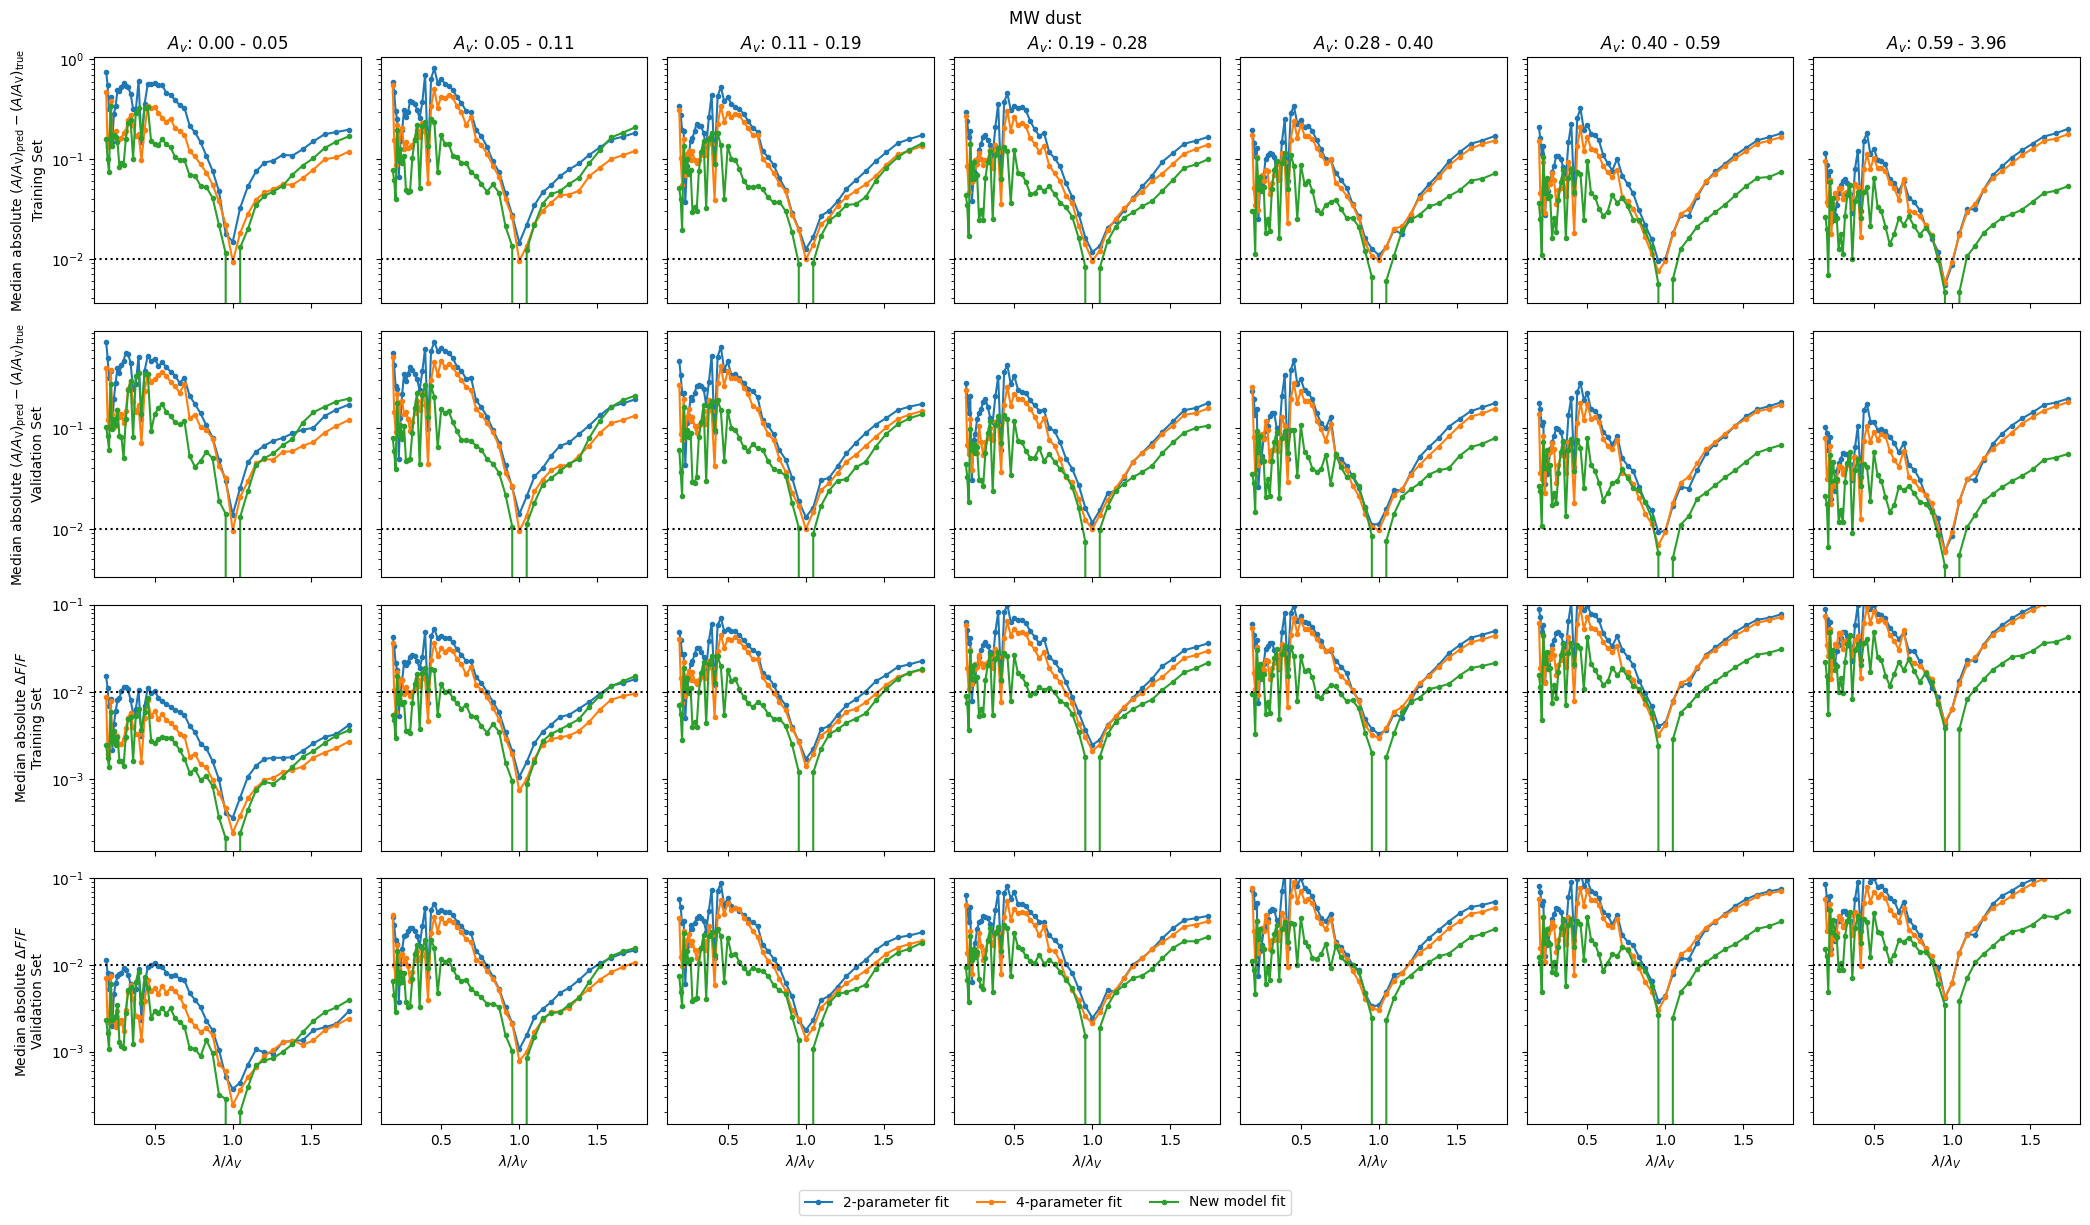

In [15]:
ini_file = 'conf/iob_44.ini'
args = OperonArgs(ini_file)

# lam_min = 0.12
# lam_max = 1.0
lam_min = args.lam_min 
lam_max = args.lam_max

npercbin = 7

# Find the percentile values of A_v to use for plotting
_, _, _, _, _, Av = fit_curves.load_data(args, 'train')
Av_perc = np.percentile(Av, np.linspace(0, 100, npercbin+1))


fig, axs = plt.subplots(4, npercbin, figsize=(3*npercbin,12), sharex=True, sharey='row')

for j, name in enumerate(['train', 'val']):

    x, ytrue, _, _, _, Av = fit_curves.load_data(args, name)
    run_name = f'{args.in_param}_{str(args.version_num)}'
    fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
    df_opt = pd.read_csv(fname_opt)
    lam = x * args.lambda_V

    m = (lam >= lam_min) & (lam <= lam_max)
    # m = np.ones_like(lam, dtype=bool)
    x = x[m]
    lam = lam[m]
    ytrue = ytrue[:,m]

    ypred_2par = np.zeros_like(ytrue)
    ypred_4par = np.zeros_like(ytrue)
    ypred_new = np.zeros_like(ytrue)

    popt_4par = df_opt[['4par_p0', '4par_p1', '4par_p2', '4par_p3']].values
    popt_2par = df_opt[['2par_B', '2par_delta']].values
    # popt_new = df_opt[['newpar_D0', 'newpar_D1', 'newpar_D2', 'newpar_D3']].values
    popt_new = df_opt[['newpar_reparam_A0', 'newpar_reparam_A1', 'newpar_reparam_A2', 'newpar_reparam_A3']].values
     
    # Get predicted curves for each galaxy
    print('')
    for i in tqdm(range(len(ytrue)), desc=f'Calculating fits for {name} set'):
        ypred_2par[i,:] = attenuation_curves.Att_Curve_2param(1e4*lam, *popt_2par[i,:])
        ypred_4par[i,:] = attenuation_curves.Li_08_fit_noratio(lam, *popt_4par[i,:])
        # ypred_new[i,:] = fit_curves.new_model(x, *popt_new[i,:])
        ypred_new[i,:] = fit_curves.new_model_reparam(x, *popt_new[i,:])

    # Calculate fractional errors on A
    frac_err_2par = (ypred_2par - ytrue) #/ ytrue
    frac_err_4par = (ypred_4par - ytrue) #/ ytrue
    frac_err_new = (ypred_new - ytrue) #/ ytrue

    # Calculate dF/F errors
    # dF_F = 10. ** (0.4 * A_v * (A_pred - A_true)) - 1.0
    dF_F_2par = 10. ** (0.4 * Av[:,None] * (ypred_2par - ytrue)) - 1.0
    dF_F_4par = 10. ** (0.4 * Av[:,None] * (ypred_4par - ytrue)) - 1.0
    dF_F_new = 10. ** (0.4 * Av[:,None] * (ypred_new - ytrue)) - 1.0

    for k in range(npercbin):
        m_Av = (Av >= Av_perc[k]) & (Av < Av_perc[k+1])
        print(f'{name} set, A_v bin {k}: {Av_perc[k]:.2f} - {Av_perc[k+1]:.2f}, N={np.sum(m_Av)}')

        for i, (errs, title) in enumerate(zip([frac_err_2par, frac_err_4par, frac_err_new],
                                            ['2-parameter fit', '4-parameter fit', 'New model fit'])):
            ax = axs[j,k]
            median_abs_err = np.median(np.abs(errs[m_Av,:]), axis=0)
            ax.plot(x, median_abs_err, marker='.', label=title, color=f'C{i}')

        for i, (errs, title) in enumerate(zip([dF_F_2par, dF_F_4par, dF_F_new],
                                            ['2-parameter fit', '4-parameter fit', 'New model fit'])):
            
            ax = axs[2+j,k]
            median_abs_err = np.median(np.abs(errs[m_Av,:]), axis=0)
            ax.plot(x, median_abs_err, marker='.', label=title, color=f'C{i}')

for ax in axs[-1,:]:
    ax.set_xlabel(r'$\lambda / \lambda_V$')

for ax in axs.flatten():
    ax.set_yscale('log')
    ax.axhline(0.01, color='k', ls=':')


for ax in axs[2:,:].flatten():
    ylim = ax.get_ylim()
    ylim = (max(ylim[0], -0.1), min(ylim[1], 0.1))
    ax.set_ylim(ylim)
   

for k in range(npercbin):
    title = f'$A_v$: {Av_perc[k]:.2f} - {Av_perc[k+1]:.2f}'
    axs[0,k].set_title(title)

# Add a single legend below the plot
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.03))

# axs[0,0].set_ylabel('Median absolute ' + r"$\Delta A / A$" + '\nTraining Set')
# axs[1,0].set_ylabel('Median absolute ' + r"$\Delta A / A$" + '\nValidation Set')
axs[0,0].set_ylabel('Median absolute ' + r"$(A / A_{\rm V})_{\rm pred} - (A / A_{\rm V})_{\rm true} $" + '\nTraining Set')
axs[1,0].set_ylabel('Median absolute ' + r"$(A / A_{\rm V})_{\rm pred} - (A / A_{\rm V})_{\rm true} $" + '\nValidation Set')
# axs[1,0].set_ylabel('Median absolute ' + r"$\Delta A / A$" + '\nValidation Set')
axs[2,0].set_ylabel('Median absolute ' + r'$\Delta F / F$' + '\nTraining Set')
axs[3,0].set_ylabel('Median absolute ' + r'$\Delta F / F$' + '\nValidation Set')
fig.align_ylabels()

fig.suptitle('MW dust')
fig.tight_layout()
fig.savefig('figs/attenuation_errors_by_Av_bins.png', bbox_inches='tight')



Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/train_data_v1.csv with 1473 galaxies.
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/train_data_v1.csv with 1473 galaxies.



Calculating fits for train set: 100%|██████████| 1473/1473 [00:00<00:00, 2203.93it/s]


Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/val_data_v1.csv with 736 galaxies.



Calculating fits for val set: 100%|██████████| 736/736 [00:00<00:00, 2222.87it/s]


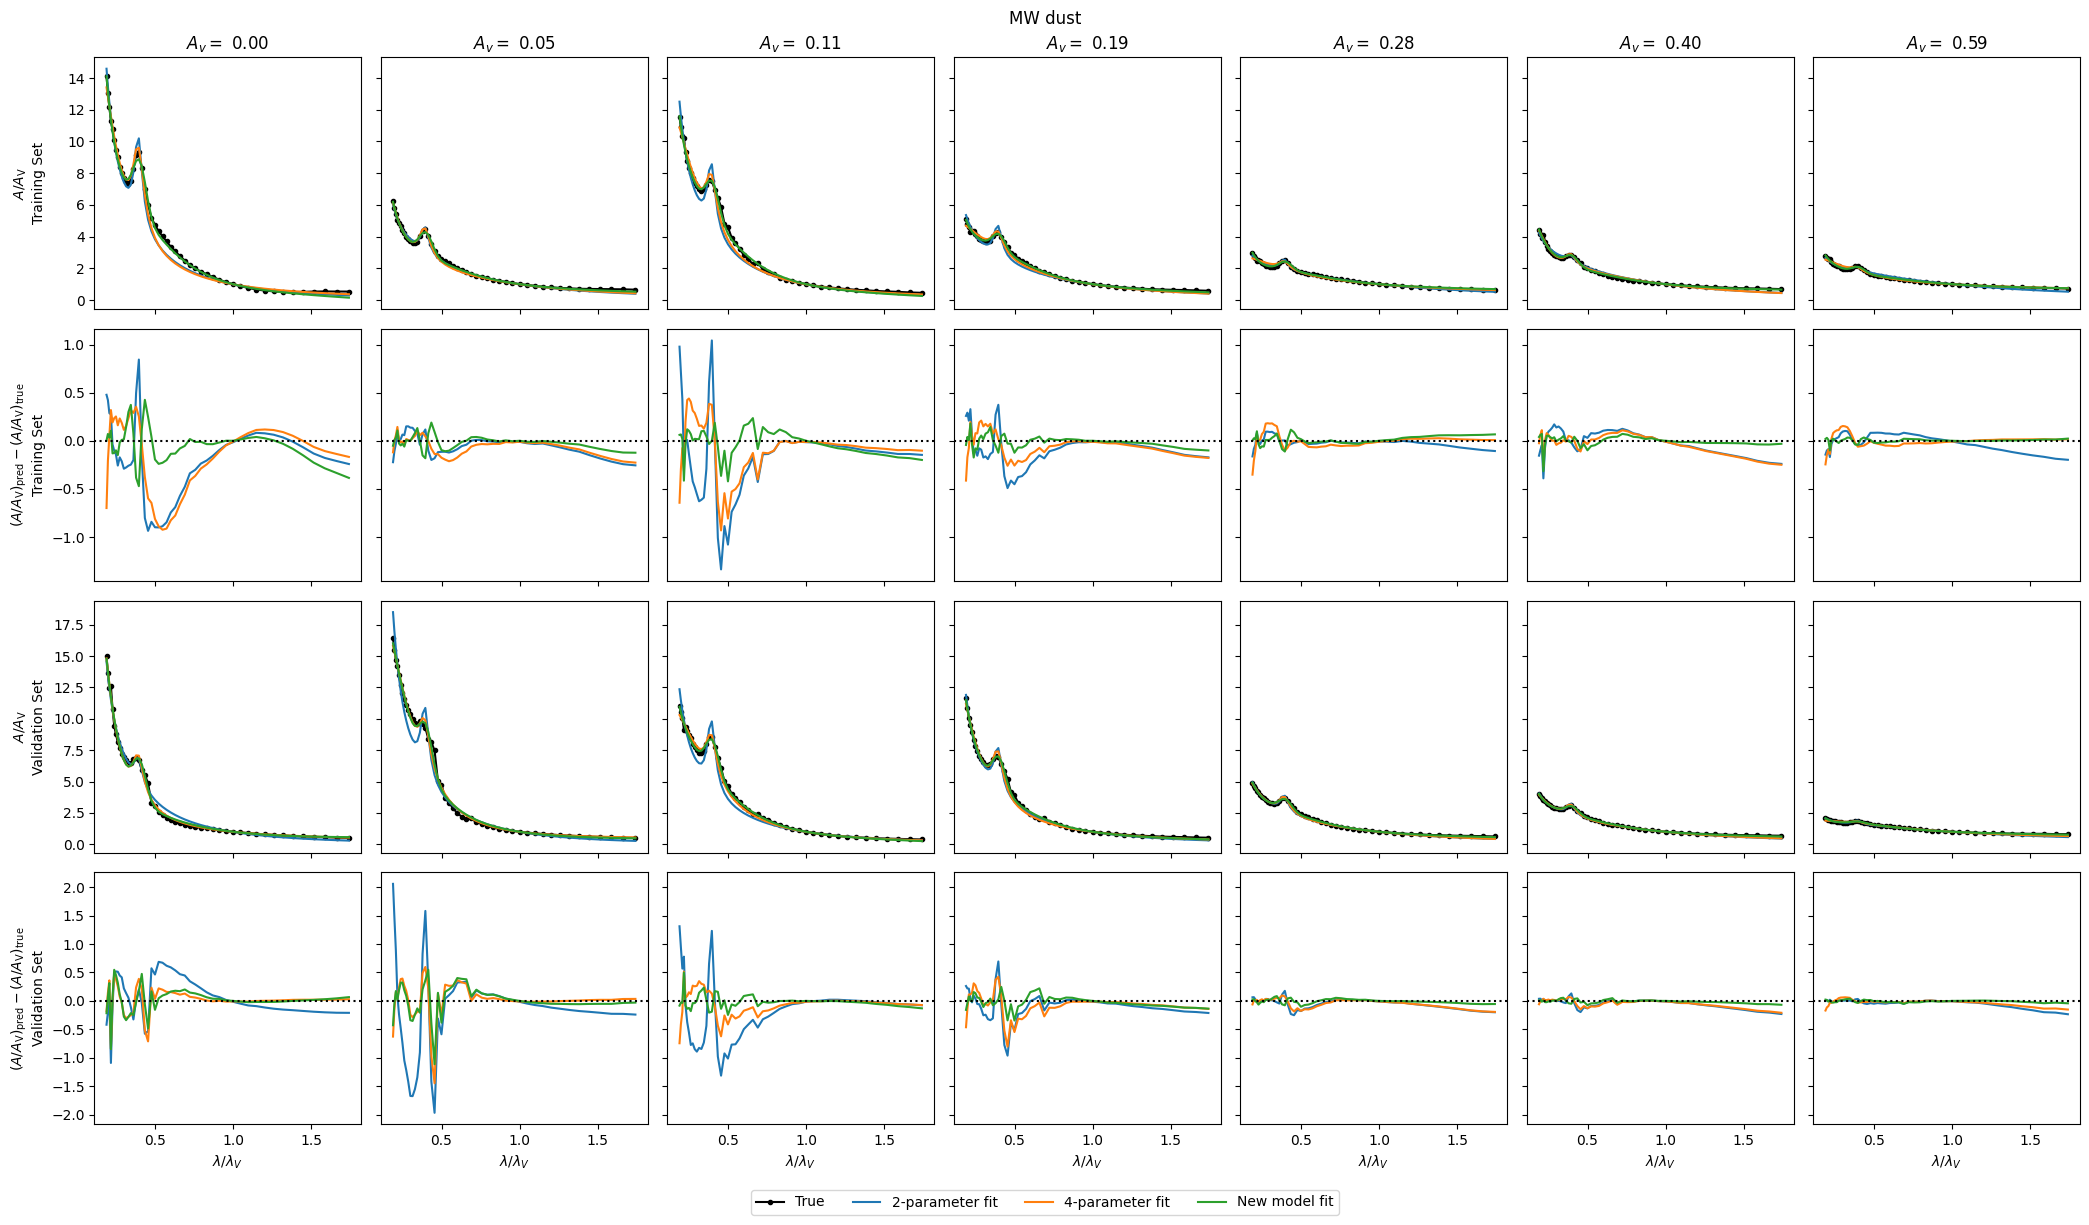

In [14]:
ini_file = 'conf/iob_44.ini'
args = OperonArgs(ini_file)

# lam_min = 0.12
# lam_max = 1.0
lam_min = args.lam_min 
lam_max = args.lam_max

npercbin = 7

# Find the percentile values of A_v to use for plotting
_, _, _, _, _, Av = fit_curves.load_data(args, 'train')
Av_perc = np.percentile(Av, np.linspace(0, 100, npercbin+1))


fig, axs = plt.subplots(4, npercbin, figsize=(3*npercbin,12), sharex=True, sharey='row')

for j, name in enumerate(['train', 'val']):

    x, ytrue, _, _, _, Av = fit_curves.load_data(args, name)
    run_name = f'{args.in_param}_{str(args.version_num)}'
    fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
    df_opt = pd.read_csv(fname_opt)
    lam = x * args.lambda_V

    m = (lam >= lam_min) & (lam <= lam_max)
    # m = np.ones_like(lam, dtype=bool)
    x = x[m]
    lam = lam[m]
    ytrue = ytrue[:,m]

    ypred_2par = np.zeros_like(ytrue)
    ypred_4par = np.zeros_like(ytrue)
    ypred_new = np.zeros_like(ytrue)

    popt_4par = df_opt[['4par_p0', '4par_p1', '4par_p2', '4par_p3']].values
    popt_2par = df_opt[['2par_B', '2par_delta']].values
    # popt_new = df_opt[['newpar_D0', 'newpar_D1', 'newpar_D2', 'newpar_D3']].values
    popt_new = df_opt[['newpar_reparam_A0', 'newpar_reparam_A1', 'newpar_reparam_A2', 'newpar_reparam_A3']].values
     
    # Get predicted curves for each galaxy
    print('')
    for i in tqdm(range(len(ytrue)), desc=f'Calculating fits for {name} set'):
        ypred_2par[i,:] = attenuation_curves.Att_Curve_2param(1e4*lam, *popt_2par[i,:])
        ypred_4par[i,:] = attenuation_curves.Li_08_fit_noratio(lam, *popt_4par[i,:])
        # ypred_new[i,:] = fit_curves.new_model(x, *popt_new[i,:])
        ypred_new[i,:] = fit_curves.new_model_reparam(x, *popt_new[i,:])

    # Calculate fractional errors on A
    frac_err_2par = (ypred_2par - ytrue) / ytrue
    frac_err_4par = (ypred_4par - ytrue) / ytrue
    frac_err_new = (ypred_new - ytrue) / ytrue

    # Calculate dF/F errors
    # dF_F = 10. ** (0.4 * A_v * (A_pred - A_true)) - 1.0
    dF_F_2par = 10. ** (0.4 * Av[:,None] * (ypred_2par - ytrue)) - 1.0
    dF_F_4par = 10. ** (0.4 * Av[:,None] * (ypred_4par - ytrue)) - 1.0
    dF_F_new = 10. ** (0.4 * Av[:,None] * (ypred_new - ytrue)) - 1.0

    for k in range(npercbin):
        m_Av = (Av >= Av_perc[k]) & (Av < Av_perc[k+1])

        m_Av = np.argmin(np.abs(Av - Av_perc[k+1]))

        axs[2*j,k].plot(x, ytrue[m_Av,:], marker='.', label='True', color='k')
        axs[2*j,k].plot(x, ypred_2par[m_Av,:], label='2-parameter fit', color='C0')
        axs[2*j,k].plot(x, ypred_4par[m_Av,:], label='4-parameter fit', color='C1')
        axs[2*j,k].plot(x, ypred_new[m_Av,:], label='New model fit', color='C2')

        axs[2*j+1,k].plot(x, ypred_2par[m_Av,:] - ytrue[m_Av,:], label='2-parameter fit', color='C0')
        axs[2*j+1,k].plot(x, ypred_4par[m_Av,:] - ytrue[m_Av,:], label='4-parameter fit', color='C1')
        axs[2*j+1,k].plot(x, ypred_new[m_Av,:] - ytrue[m_Av,:], label='New model fit', color='C2')

for ax in axs[-1,:]:
    ax.set_xlabel(r'$\lambda / \lambda_V$')

for ax in axs[1,:]:
    ax.axhline(0.0, color='k', ls=':')

for ax in axs[3,:]:
    ax.axhline(0.0, color='k', ls=':')


# for ax in axs[2:,:].flatten():
#     ylim = ax.get_ylim()å
#     ylim = (max(ylim[0], -0.1), min(ylim[1], 0.1))
#     ax.set_ylim(ylim)
   

for k in range(npercbin):
    title = f'$A_v = $ {Av_perc[k]:.2f}'
    axs[0,k].set_title(title)

# Add a single legend below the plot
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.03))

axs[0,0].set_ylabel(r"$A / A_{\rm V}$" + '\nTraining Set')
axs[1,0].set_ylabel(r"$(A / A_{\rm V})_{\rm pred} - (A / A_{\rm V})_{\rm true}$" + '\nTraining Set')
axs[2,0].set_ylabel(r"$A / A_{\rm V}$" + '\nValidation Set')
axs[3,0].set_ylabel(r"$(A / A_{\rm V})_{\rm pred} - (A / A_{\rm V})_{\rm true}$" + '\nValidation Set')
fig.align_ylabels()
fig.suptitle('MW dust')
fig.tight_layout()
fig.savefig('figs/attenuation_examples_by_Av_bins.png', bbox_inches='tight')


# SMC dust mixture


Reading from configuration file: conf/iob_47.ini

Reading from configuration file: conf/selection_2.ini
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/val_data_v2.csv with 474 galaxies.
Loaded 474 galaxies with 49 x values each for val data


100%|██████████| 474/474 [00:01<00:00, 462.28it/s]


Calculating fits for val set: 100%|██████████| 474/474 [00:00<00:00, 1815.58it/s]



Mean absolute errors for val set:
	2-parameter fit: 0.1552
	4-parameter fit: 0.0572
	New model fit: 0.0736

Mean absolute dF/F errors for val set:
	2-parameter fit: 0.0463
	4-parameter fit: 0.0150
	New model fit: 0.0200

Mean absolute errors for val set:
	2-parameter fit: 0.1552
	4-parameter fit: 0.0572
	New model fit: 0.0736

Mean absolute dF/F errors for val set:
	2-parameter fit: 0.0463
	4-parameter fit: 0.0150
	New model fit: 0.0200

Mean absolute errors for val set:
	2-parameter fit: 0.1552
	4-parameter fit: 0.0572
	New model fit: 0.0736

Mean absolute dF/F errors for val set:
	2-parameter fit: 0.0463
	4-parameter fit: 0.0150
	New model fit: 0.0200


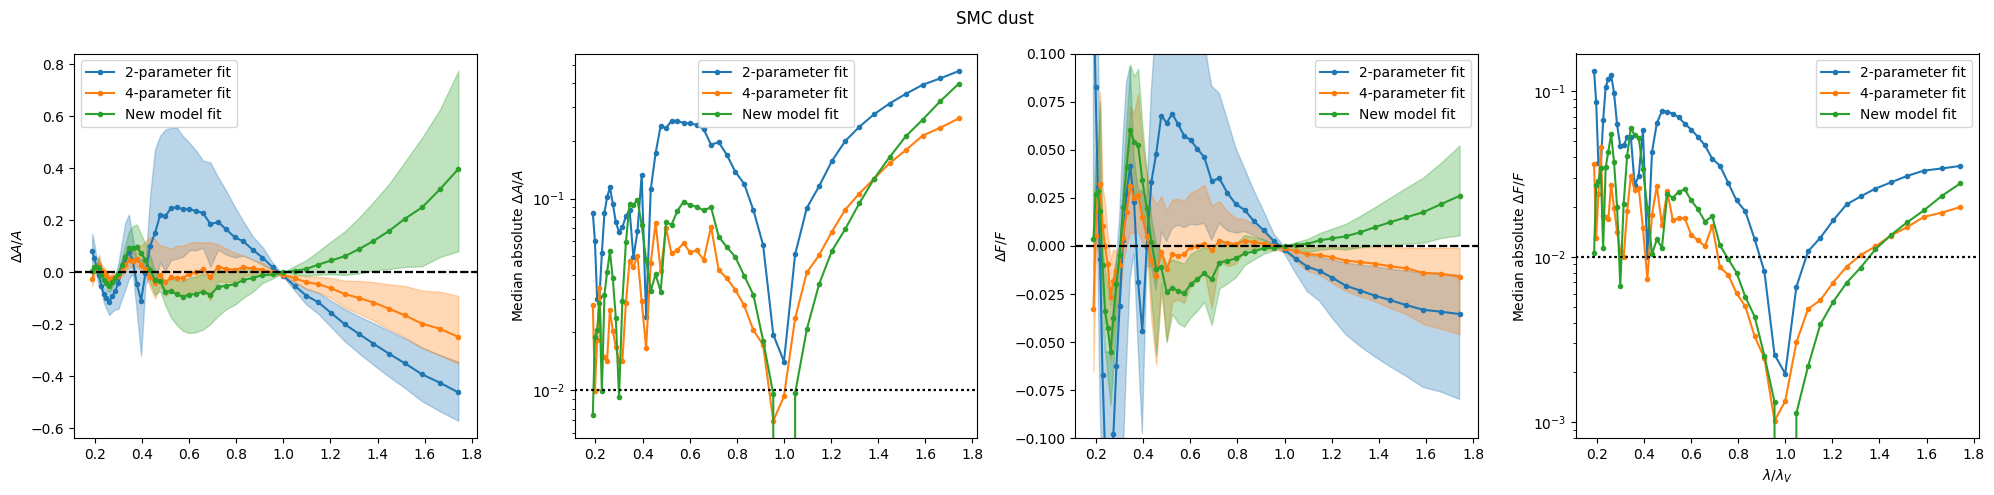

In [13]:
ini_file = 'conf/iob_47.ini' # SMC

args = OperonArgs(ini_file)

# lam_min = 0.12
# lam_max = 1.0
lam_min = args.lam_min 
lam_max = args.lam_max

fig, axs = plt.subplots(1, 4, figsize=(20,5), sharex=True)

name = 'val'

x, ytrue, _, _, _, Av = fit_curves.load_data(args, name)
run_name = f'{args.in_param}_{str(args.version_num)}'
fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
df_opt = pd.read_csv(fname_opt)
lam = x * args.lambda_V

m = (lam >= lam_min) & (lam <= lam_max)
# m = np.ones_like(lam, dtype=bool)
x = x[m]
lam = lam[m]
ytrue = ytrue[:,m]

ypred_2par = np.zeros_like(ytrue)
ypred_4par = np.zeros_like(ytrue)
ypred_new = np.zeros_like(ytrue)

popt_4par = df_opt[['4par_p0', '4par_p1', '4par_p2', '4par_p3']].values
popt_2par = df_opt[['2par_B', '2par_delta']].values
# popt_new = df_opt[['newpar_D0', 'newpar_D1', 'newpar_D2', 'newpar_D3']].values
popt_new = df_opt[['newpar_reparam_A0', 'newpar_reparam_A1', 'newpar_reparam_A2', 'newpar_reparam_A3']].values
    
# Get predicted curves for each galaxy
print('')
for i in tqdm(range(len(ytrue)), desc=f'Calculating fits for {name} set'):
    ypred_2par[i,:] = attenuation_curves.Att_Curve_2param(1e4*lam, *popt_2par[i,:])
    ypred_4par[i,:] = attenuation_curves.Li_08_fit_noratio(lam, *popt_4par[i,:])
    # ypred_new[i,:] = fit_curves.new_model(x, *popt_new[i,:])
    ypred_new[i,:] = fit_curves.new_model_reparam(x, *popt_new[i,:])

# Calculate fractional errors on A
frac_err_2par = (ypred_2par - ytrue) / ytrue
frac_err_4par = (ypred_4par - ytrue) / ytrue
frac_err_new = (ypred_new - ytrue) / ytrue

# Calculate dF/F errors
# dF_F = 10. ** (0.4 * A_v * (A_pred - A_true)) - 1.0
dF_F_2par = 10. ** (0.4 * Av[:,None] * (ypred_2par - ytrue)) - 1.0
dF_F_4par = 10. ** (0.4 * Av[:,None] * (ypred_4par - ytrue)) - 1.0
dF_F_new = 10. ** (0.4 * Av[:,None] * (ypred_new - ytrue)) - 1.0

for i, (errs, title) in enumerate(zip([frac_err_2par, frac_err_4par, frac_err_new],
                                        ['2-parameter fit', '4-parameter fit', 'New model fit'])):
    ax = axs[0]
    median_err = np.median(errs, axis=0)
    p16 = np.percentile(errs, 16., axis=0)
    p84 = np.percentile(errs, 84., axis=0)
    ax.fill_between(x, p16, p84, color=f'C{i}', alpha=0.3)
    ax.plot(x, median_err, marker='.', label=title, color=f'C{i}')
    ax.axhline(0., color='k', ls='--')
    if i == 0:
        ax.set_ylabel(r"$\Delta A / A$")
    ax.legend()

    ax = axs[1]
    median_abs_err = np.median(np.abs(errs), axis=0)
    ax.plot(x, median_abs_err, marker='.', label=title, color=f'C{i}')
    if i == 0:
        ax.set_ylabel('Median absolute ' + r"$\Delta A / A$")
    ax.legend()

for i, (errs, title) in enumerate(zip([dF_F_2par, dF_F_4par, dF_F_new],
                                        ['2-parameter fit', '4-parameter fit', 'New model fit'])):
    ax = axs[2]
    median_err = np.median(errs, axis=0)
    p16 = np.percentile(errs, 16., axis=0)
    p84 = np.percentile(errs, 84., axis=0)
    ax.fill_between(x, p16, p84, color=f'C{i}', alpha=0.3)
    ax.plot(x, median_err, marker='.', label=title, color=f'C{i}')
    ax.axhline(0., color='k', ls='--')
    if i == 0:
        ax.set_ylabel(r'$\Delta F / F$')
    ax.legend()
    
    ax = axs[3]
    median_abs_err = np.median(np.abs(errs), axis=0)
    ax.plot(x, median_abs_err, marker='.', label=title, color=f'C{i}')
    ax.set_xlabel(r'$\lambda / \lambda_V$')
    if i == 0:
        ax.set_ylabel('Median absolute ' + r'$\Delta F / F$')
    ax.legend()

    ylim = axs[2].get_ylim()
    ylim = (max(ylim[0], -0.1), min(ylim[1], 0.1))
    axs[2].set_ylim(ylim)

    for ax in [axs[1], axs[3]]:
        ax.set_yscale('log')
        ax.axhline(0.01, color='k', ls=':')

    # For each fit, print the median absolute errors on A over the wavelength range
    print('\nMean absolute errors for', name, 'set:')
    for i, (errs, title) in enumerate(zip([frac_err_2par, frac_err_4par, frac_err_new],
                                          ['2-parameter fit', '4-parameter fit', 'New model fit'])):
        mean_abs_err = np.median(np.abs(errs), axis=0)
        overall_mean_abs_err = np.mean(mean_abs_err)
        print(f'\t{title}: {overall_mean_abs_err:.4f}')

    
    # For each fit, print the median absolute dF/F errors over the wavelength range
    print('\nMean absolute dF/F errors for', name, 'set:')
    for i, (errs, title) in enumerate(zip([dF_F_2par, dF_F_4par, dF_F_new],
                                          ['2-parameter fit', '4-parameter fit', 'New model fit'])):
        mean_abs_err = np.median(np.abs(errs), axis=0)
        overall_median_abs_err = np.mean(mean_abs_err)
        print(f'\t{title}: {overall_median_abs_err:.4f}')

fig.suptitle('SMC dust')
fig.tight_layout()
fig.savefig('figs/attenuation_errors_combined_SMC.png', bbox_inches='tight')



Reading from configuration file: conf/iob_47.ini

Reading from configuration file: conf/selection_2.ini
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/val_data_v2.csv with 474 galaxies.
Loaded 474 galaxies with 49 x values each for val data


100%|██████████| 474/474 [00:01<00:00, 465.88it/s]


Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/val_data_v2.csv with 474 galaxies.
Loaded 474 galaxies with 49 x values each for val data


100%|██████████| 474/474 [00:01<00:00, 445.75it/s]


Calculating fits for val set: 100%|██████████| 474/474 [00:00<00:00, 1800.59it/s]


val set, A_v bin 0: -0.00 - 0.05, N=68
val set, A_v bin 1: 0.05 - 0.08, N=68
val set, A_v bin 2: 0.08 - 0.13, N=67
val set, A_v bin 3: 0.13 - 0.18, N=68
val set, A_v bin 4: 0.18 - 0.24, N=67
val set, A_v bin 5: 0.24 - 0.39, N=68
val set, A_v bin 6: 0.39 - 2.34, N=67


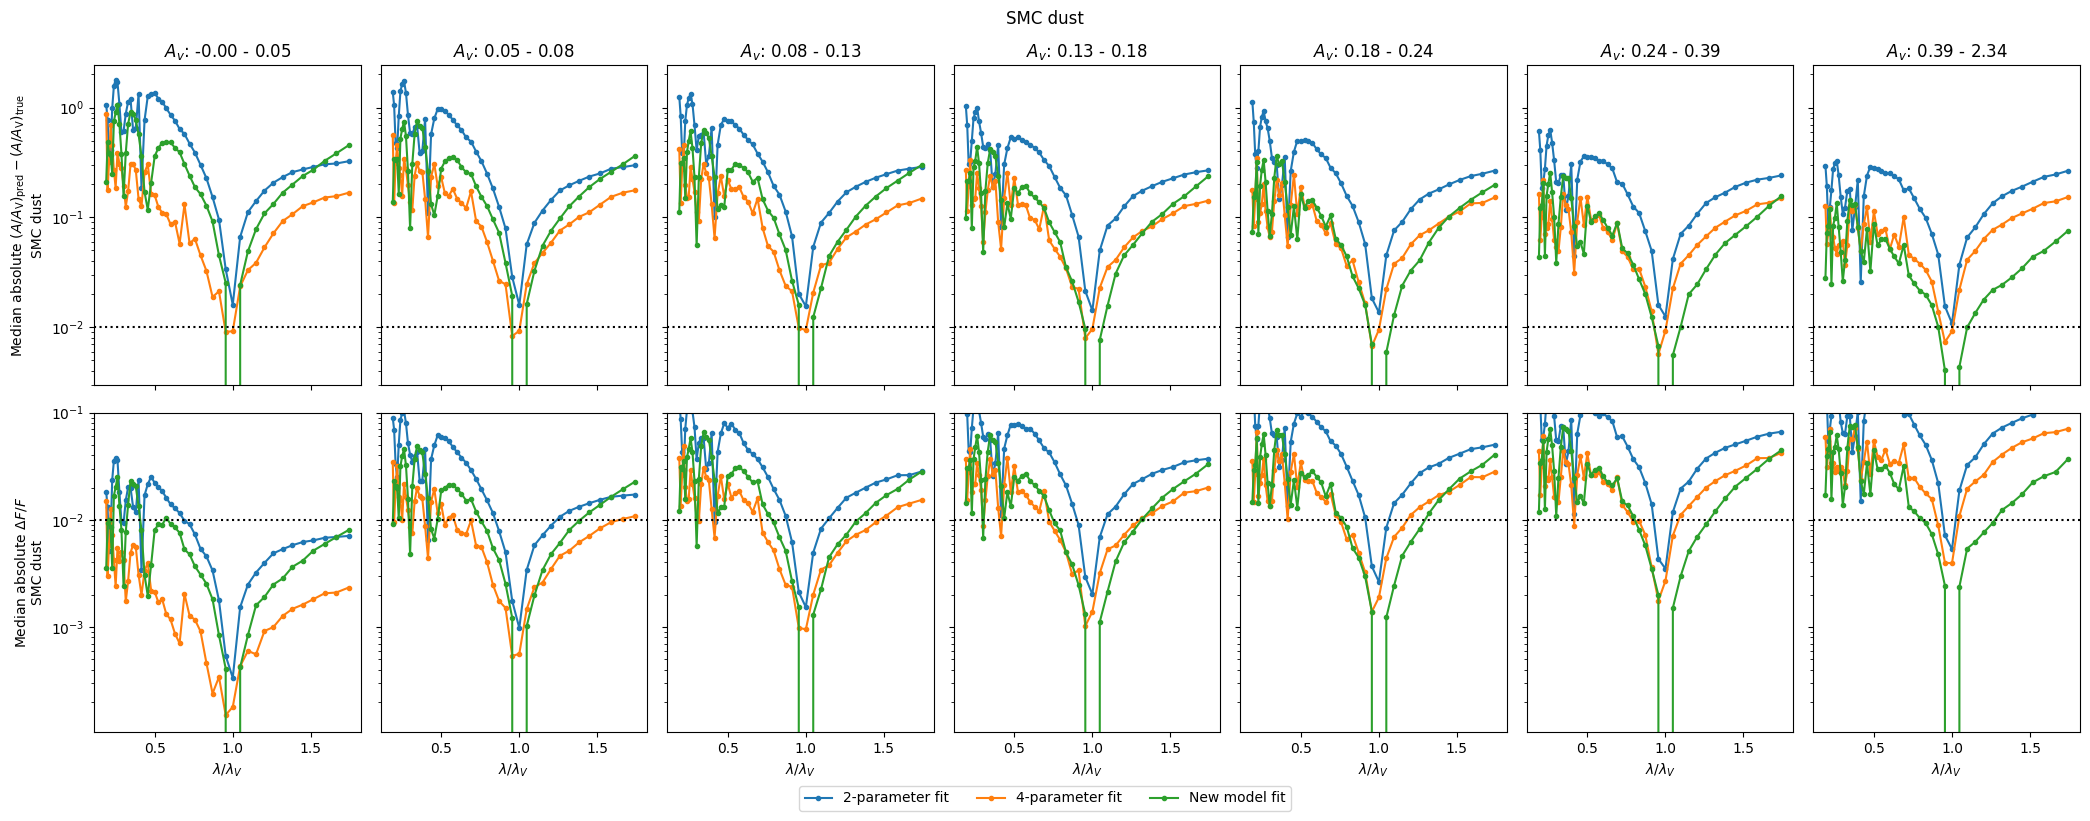

In [11]:
ini_file = 'conf/iob_47.ini'
args = OperonArgs(ini_file)

# lam_min = 0.12
# lam_max = 1.0
lam_min = args.lam_min 
lam_max = args.lam_max

npercbin = 7
name = 'val'

# Find the percentile values of A_v to use for plotting
_, _, _, _, _, Av = fit_curves.load_data(args, 'val')
Av_perc = np.percentile(Av, np.linspace(0, 100, npercbin+1))


fig, axs = plt.subplots(2, npercbin, figsize=(3*npercbin,8), sharex=True, sharey='row')


x, ytrue, _, _, _, Av = fit_curves.load_data(args, name)
run_name = f'{args.in_param}_{str(args.version_num)}'
fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
df_opt = pd.read_csv(fname_opt)
lam = x * args.lambda_V

m = (lam >= lam_min) & (lam <= lam_max)
# m = np.ones_like(lam, dtype=bool)
x = x[m]
lam = lam[m]
ytrue = ytrue[:,m]

ypred_2par = np.zeros_like(ytrue)
ypred_4par = np.zeros_like(ytrue)
ypred_new = np.zeros_like(ytrue)

popt_4par = df_opt[['4par_p0', '4par_p1', '4par_p2', '4par_p3']].values
popt_2par = df_opt[['2par_B', '2par_delta']].values
# popt_new = df_opt[['newpar_D0', 'newpar_D1', 'newpar_D2', 'newpar_D3']].values
popt_new = df_opt[['newpar_reparam_A0', 'newpar_reparam_A1', 'newpar_reparam_A2', 'newpar_reparam_A3']].values
     
# Get predicted curves for each galaxy
print('')
for i in tqdm(range(len(ytrue)), desc=f'Calculating fits for {name} set'):
    ypred_2par[i,:] = attenuation_curves.Att_Curve_2param(1e4*lam, *popt_2par[i,:])
    ypred_4par[i,:] = attenuation_curves.Li_08_fit_noratio(lam, *popt_4par[i,:])
    # ypred_new[i,:] = fit_curves.new_model(x, *popt_new[i,:])
    ypred_new[i,:] = fit_curves.new_model_reparam(x, *popt_new[i,:])

# Calculate fractional errors on A
frac_err_2par = (ypred_2par - ytrue) #/ ytrue
frac_err_4par = (ypred_4par - ytrue) #/ ytrue
frac_err_new = (ypred_new - ytrue) #/ ytrue

# Calculate dF/F errors
# dF_F = 10. ** (0.4 * A_v * (A_pred - A_true)) - 1.0
dF_F_2par = 10. ** (0.4 * Av[:,None] * (ypred_2par - ytrue)) - 1.0
dF_F_4par = 10. ** (0.4 * Av[:,None] * (ypred_4par - ytrue)) - 1.0
dF_F_new = 10. ** (0.4 * Av[:,None] * (ypred_new - ytrue)) - 1.0

for k in range(npercbin):
    m_Av = (Av >= Av_perc[k]) & (Av < Av_perc[k+1])
    print(f'{name} set, A_v bin {k}: {Av_perc[k]:.2f} - {Av_perc[k+1]:.2f}, N={np.sum(m_Av)}')

    for i, (errs, title) in enumerate(zip([frac_err_2par, frac_err_4par, frac_err_new],
                                        ['2-parameter fit', '4-parameter fit', 'New model fit'])):
        ax = axs[0,k]
        median_abs_err = np.median(np.abs(errs[m_Av,:]), axis=0)
        ax.plot(x, median_abs_err, marker='.', label=title, color=f'C{i}')

    for i, (errs, title) in enumerate(zip([dF_F_2par, dF_F_4par, dF_F_new],
                                        ['2-parameter fit', '4-parameter fit', 'New model fit'])):
        
        ax = axs[1,k]
        median_abs_err = np.median(np.abs(errs[m_Av,:]), axis=0)
        ax.plot(x, median_abs_err, marker='.', label=title, color=f'C{i}')

for ax in axs[-1,:]:
    ax.set_xlabel(r'$\lambda / \lambda_V$')

for ax in axs.flatten():
    ax.set_yscale('log')
    ax.axhline(0.01, color='k', ls=':')


for ax in axs[1,:]:
    ylim = ax.get_ylim()
    ylim = (max(ylim[0], -0.1), min(ylim[1], 0.1))
    ax.set_ylim(ylim)
   

for k in range(npercbin):
    title = f'$A_v$: {Av_perc[k]:.2f} - {Av_perc[k+1]:.2f}'
    axs[0,k].set_title(title)

# Add a single legend below the plot
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.03))

axs[0,0].set_ylabel('Median absolute ' + r"$(A / A_{\rm V})_{\rm pred} - (A / A_{\rm V})_{\rm true} $" + '\nSMC dust')
axs[1,0].set_ylabel('Median absolute ' + r'$\Delta F / F$' + '\nSMC dust')
fig.align_ylabels()

fig.suptitle('SMC dust')

fig.tight_layout()
fig.savefig('figs/attenuation_errors_by_Av_bins_SMC.png', bbox_inches='tight')



Reading from configuration file: conf/iob_47.ini

Reading from configuration file: conf/selection_2.ini
Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/val_data_v2.csv with 474 galaxies.
Loaded 474 galaxies with 49 x values each for val data


100%|██████████| 474/474 [00:00<00:00, 487.74it/s]


Loaded original data from /mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/val_data_v2.csv with 474 galaxies.
Loaded 474 galaxies with 49 x values each for val data


100%|██████████| 474/474 [00:00<00:00, 489.84it/s]


Calculating fits for val set: 100%|██████████| 474/474 [00:00<00:00, 1801.68it/s]


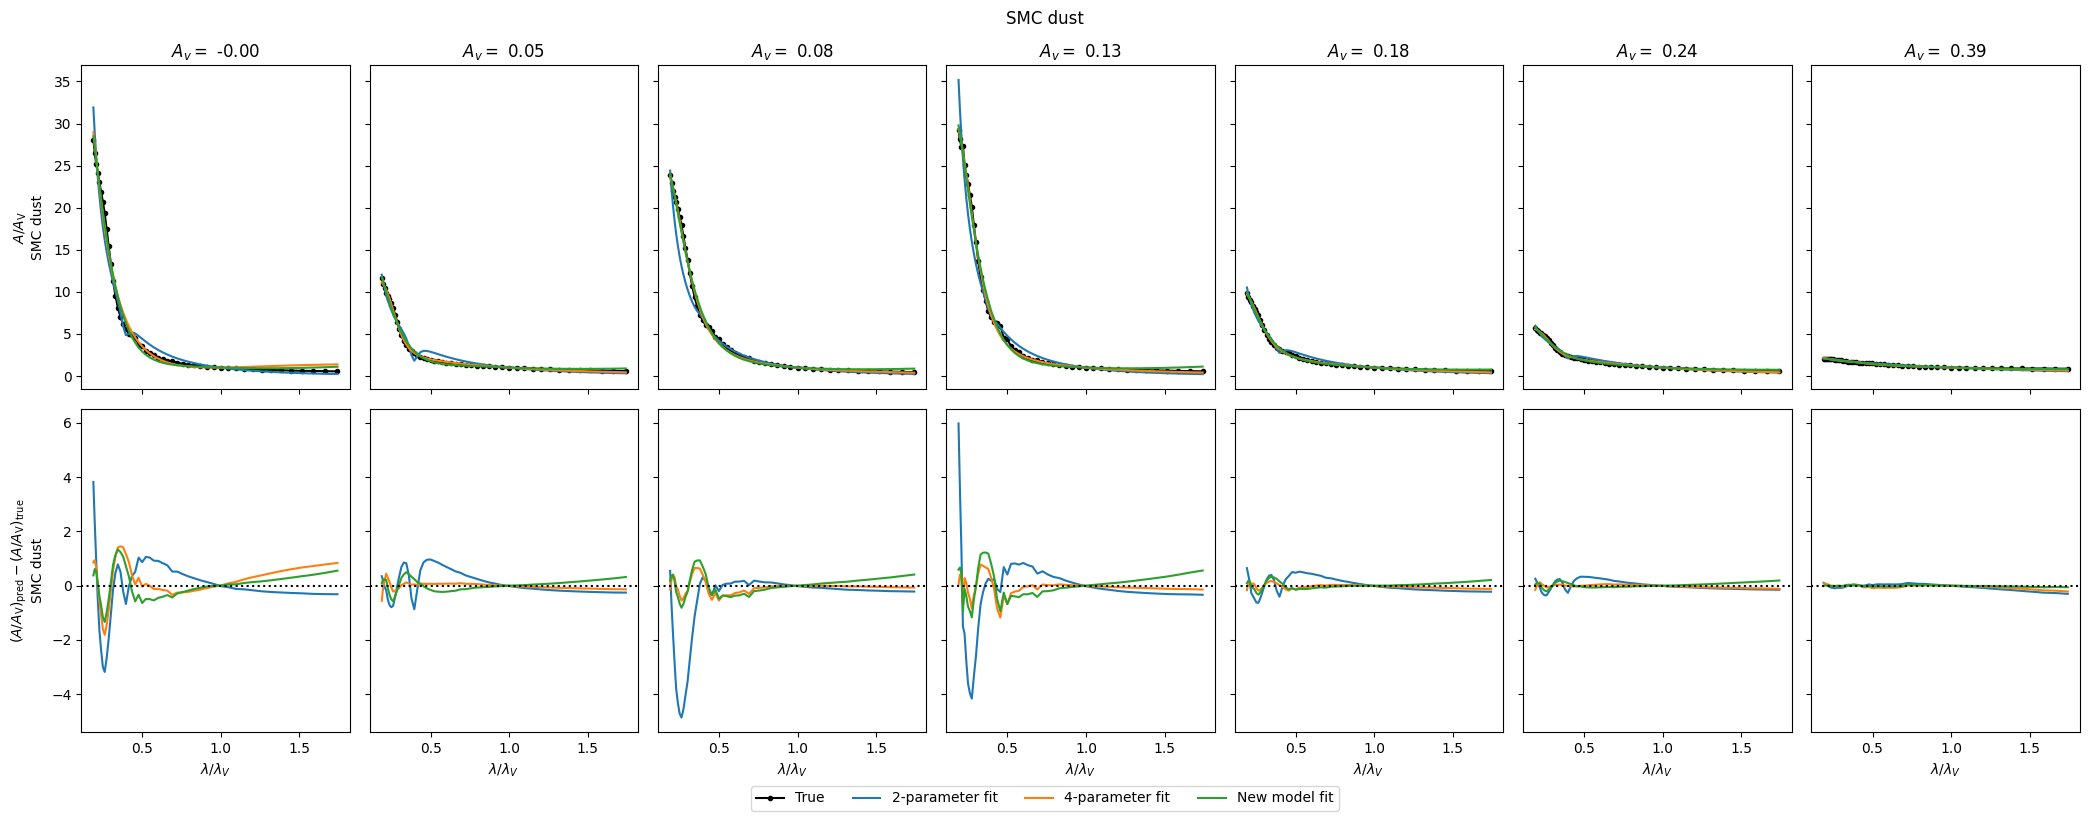

In [12]:
ini_file = 'conf/iob_47.ini'
args = OperonArgs(ini_file)

# lam_min = 0.12
# lam_max = 1.0
lam_min = args.lam_min 
lam_max = args.lam_max

npercbin = 7

# Find the percentile values of A_v to use for plotting
_, _, _, _, _, Av = fit_curves.load_data(args, 'val')
Av_perc = np.percentile(Av, np.linspace(0, 100, npercbin+1))

name = 'val'


fig, axs = plt.subplots(2, npercbin, figsize=(3*npercbin,8), sharex=True, sharey='row')


x, ytrue, _, _, _, Av = fit_curves.load_data(args, name)
run_name = f'{args.in_param}_{str(args.version_num)}'
fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
df_opt = pd.read_csv(fname_opt)
lam = x * args.lambda_V

m = (lam >= lam_min) & (lam <= lam_max)
# m = np.ones_like(lam, dtype=bool)
x = x[m]
lam = lam[m]
ytrue = ytrue[:,m]

ypred_2par = np.zeros_like(ytrue)
ypred_4par = np.zeros_like(ytrue)
ypred_new = np.zeros_like(ytrue)

popt_4par = df_opt[['4par_p0', '4par_p1', '4par_p2', '4par_p3']].values
popt_2par = df_opt[['2par_B', '2par_delta']].values
# popt_new = df_opt[['newpar_D0', 'newpar_D1', 'newpar_D2', 'newpar_D3']].values
popt_new = df_opt[['newpar_reparam_A0', 'newpar_reparam_A1', 'newpar_reparam_A2', 'newpar_reparam_A3']].values
     
# Get predicted curves for each galaxy
print('')
for i in tqdm(range(len(ytrue)), desc=f'Calculating fits for {name} set'):
    ypred_2par[i,:] = attenuation_curves.Att_Curve_2param(1e4*lam, *popt_2par[i,:])
    ypred_4par[i,:] = attenuation_curves.Li_08_fit_noratio(lam, *popt_4par[i,:])
    # ypred_new[i,:] = fit_curves.new_model(x, *popt_new[i,:])
    ypred_new[i,:] = fit_curves.new_model_reparam(x, *popt_new[i,:])

# Calculate fractional errors on A
frac_err_2par = (ypred_2par - ytrue) / ytrue
frac_err_4par = (ypred_4par - ytrue) / ytrue
frac_err_new = (ypred_new - ytrue) / ytrue

# Calculate dF/F errors
# dF_F = 10. ** (0.4 * A_v * (A_pred - A_true)) - 1.0
dF_F_2par = 10. ** (0.4 * Av[:,None] * (ypred_2par - ytrue)) - 1.0
dF_F_4par = 10. ** (0.4 * Av[:,None] * (ypred_4par - ytrue)) - 1.0
dF_F_new = 10. ** (0.4 * Av[:,None] * (ypred_new - ytrue)) - 1.0

for k in range(npercbin):
    m_Av = (Av >= Av_perc[k]) & (Av < Av_perc[k+1])

    m_Av = np.argmin(np.abs(Av - Av_perc[k+1]))

    axs[0,k].plot(x, ytrue[m_Av,:], marker='.', label='True', color='k')
    axs[0,k].plot(x, ypred_2par[m_Av,:], label='2-parameter fit', color='C0')
    axs[0,k].plot(x, ypred_4par[m_Av,:], label='4-parameter fit', color='C1')
    axs[0,k].plot(x, ypred_new[m_Av,:], label='New model fit', color='C2')

    axs[1,k].plot(x, ypred_2par[m_Av,:] - ytrue[m_Av,:], label='2-parameter fit', color='C0')
    axs[1,k].plot(x, ypred_4par[m_Av,:] - ytrue[m_Av,:], label='4-parameter fit', color='C1')
    axs[1,k].plot(x, ypred_new[m_Av,:] - ytrue[m_Av,:], label='New model fit', color='C2')

for ax in axs[-1,:]:
    ax.set_xlabel(r'$\lambda / \lambda_V$')

for ax in axs[1,:]:
    ax.axhline(0.0, color='k', ls=':')
   

for k in range(npercbin):
    title = f'$A_v = $ {Av_perc[k]:.2f}'
    axs[0,k].set_title(title)

# Add a single legend below the plot
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.03))

axs[0,0].set_ylabel(r"$A / A_{\rm V}$" + '\nSMC dust')
axs[1,0].set_ylabel(r"$(A / A_{\rm V})_{\rm pred} - (A / A_{\rm V})_{\rm true}$" + '\nSMC dust')
fig.align_ylabels()
fig.suptitle('SMC dust')

fig.tight_layout()
fig.savefig('figs/attenuation_examples_by_Av_bins_SMC.png', bbox_inches='tight')


Plot distribution of the found parameters


Reading from configuration file: conf/iob_47.ini

Reading from configuration file: conf/selection_2.ini
Number of D0 == 0: 459 of 474


Text(0.5, 1.0, 'Changed parameters\nSpearman correlation matrix')

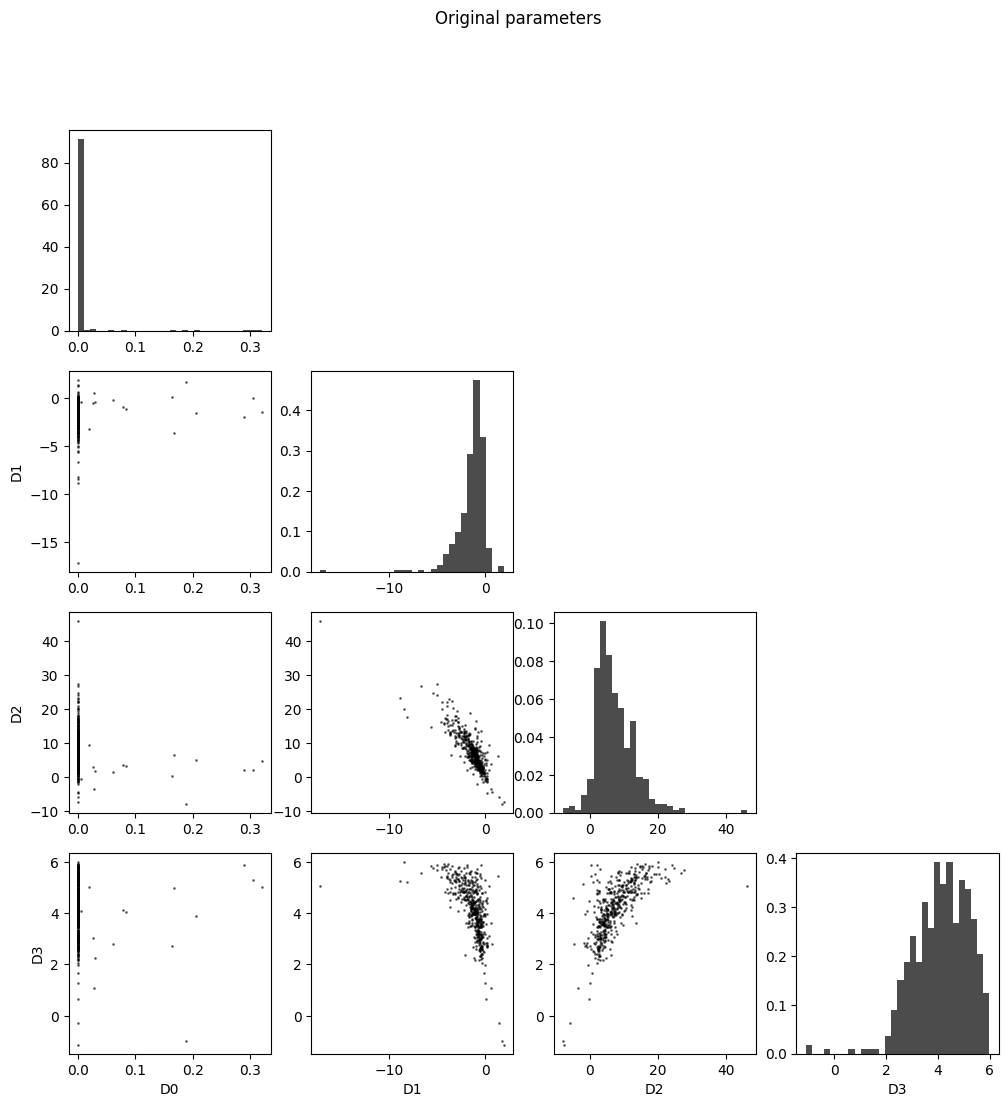

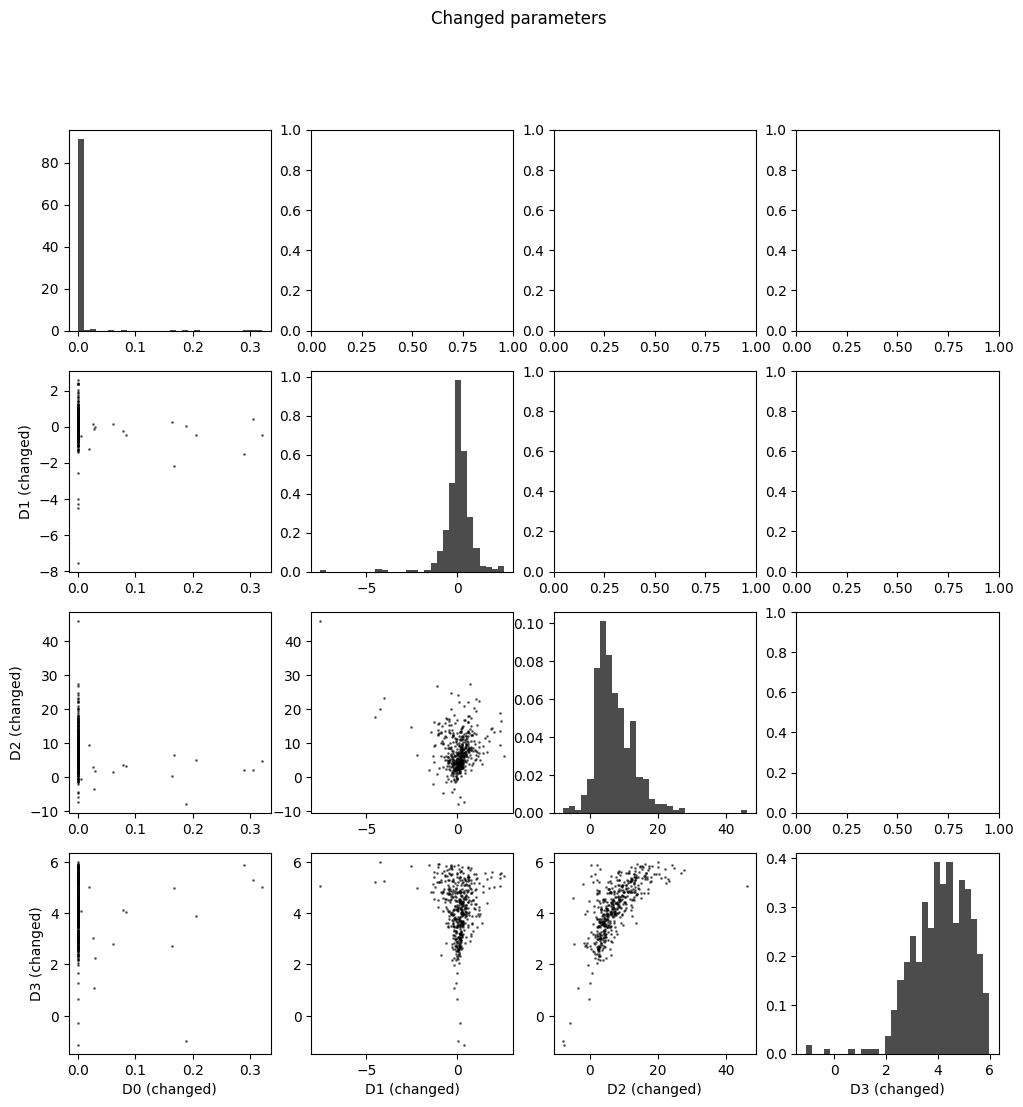

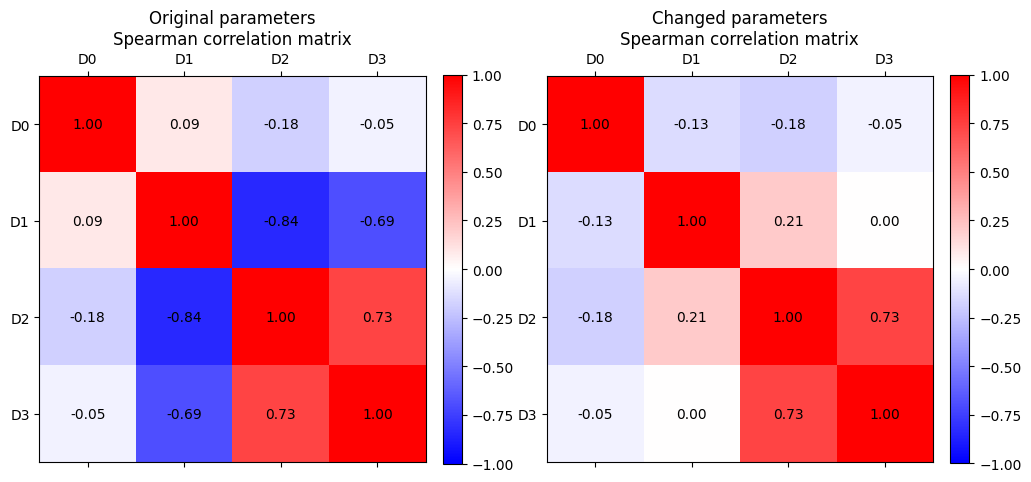

In [32]:
name = 'val'

ini_file = 'conf/iob_47.ini'
args = OperonArgs(ini_file)

run_name = f'{args.in_param}_{str(args.version_num)}'
fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
df_opt = pd.read_csv(fname_opt)
popt_new = df_opt[['newpar_D0', 'newpar_D1', 'newpar_D2', 'newpar_D3']].values

fig1, axs1 = plt.subplots(popt_new.shape[1], popt_new.shape[1], figsize=(12,12))
fig2, axs2 = plt.subplots(popt_new.shape[1], popt_new.shape[1], figsize=(12,12))
fig3, axs3 = plt.subplots(1, 2, figsize=(12,6))

# Changing parameters to reduce correlations
popt_new_changed = popt_new.copy()
popt_new_changed[:,1] = popt_new_changed[:,1] + 0.209 * popt_new_changed[:,2]
D0 = popt_new[:,0]
m = D0 == 0.0
print(f'Number of D0 == 0: {np.sum(m)} of {len(D0)}')
# D3 = popt_new[:,3]
# x = np.log(D0) - 0.173
# y = D3 - 3.258
# theta = 0.598
# popt_new_changed[:,0] = np.cos(theta) * x - np.sin(theta) * y
# popt_new_changed[:,3] = np.sin(theta) * x + np.cos(theta) * y

for i in range(popt_new.shape[1]):
    for j in range(popt_new.shape[1]):
        ax1 = axs1[i,j]
        ax2 = axs2[i,j]
        if i == j:
            ax1.hist(popt_new[:,i], bins=30, alpha=0.7, color='k', density=True)
            ax2.hist(popt_new_changed[:,i], bins=30, alpha=0.7, color='k', density=True)
        elif i > j:
            ax1.scatter(popt_new[:,j], popt_new[:,i], s=1, alpha=0.5, color='k')
            ax2.scatter(popt_new_changed[:,j], popt_new_changed[:,i], s=1, alpha=0.5, color='k')
        else:
            ax1.axis('off')

corr_matrix, pval_matrix = scipy.stats.spearmanr(popt_new, axis=0)
corr_matrix_changed, pval_matrix_changed = scipy.stats.spearmanr(popt_new_changed, axis=0)
im3 = axs3[0].matshow(corr_matrix, vmin=-1, vmax=1, cmap='bwr')
im4 = axs3[1].matshow(corr_matrix_changed, vmin=-1, vmax=1, cmap='bwr')

# Print values on the correlation matrices
for (i, j), val in np.ndenumerate(corr_matrix):
    axs3[0].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')
for (i, j), val in np.ndenumerate(corr_matrix_changed):
    axs3[1].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')

# Add colorbars to correlation plots
fig3.colorbar(im3, ax=axs3[0], fraction=0.046, pad=0.04)
fig3.colorbar(im4, ax=axs3[1], fraction=0.046, pad=0.04)

for i in range(1, popt_new.shape[1]):
    axs1[i,0].set_ylabel(f'D{i}')
    axs2[i,0].set_ylabel(f'D{i} (changed)')
for j in range(popt_new.shape[1]):
    axs1[-1,j].set_xlabel(f'D{j}')
    axs2[-1,j].set_xlabel(f'D{j} (changed)')

xticks = [f'D{i}' for i in range(popt_new.shape[1])]
yticks = [f'D{i}' for i in range(popt_new.shape[1])]
for ax in axs3:
    ax.set_xticks(np.arange(len(xticks)))
    ax.set_yticks(np.arange(len(yticks)))
    ax.set_xticklabels(xticks)
    ax.set_yticklabels(yticks)


fig1.suptitle('Original parameters')
fig2.suptitle('Changed parameters')
axs3[0].set_title('Original parameters\nSpearman correlation matrix')
axs3[1].set_title('Changed parameters\nSpearman correlation matrix')

# Distribution of Optimised Parameters


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini
Optimal rotation to reduce D1-D2 correlation: 0.257
Optimal rotation to reduce D1-D2 correlation: 0.262


Text(0.5, 0.98, 'Spearman Correlations - Transformed Parameters')

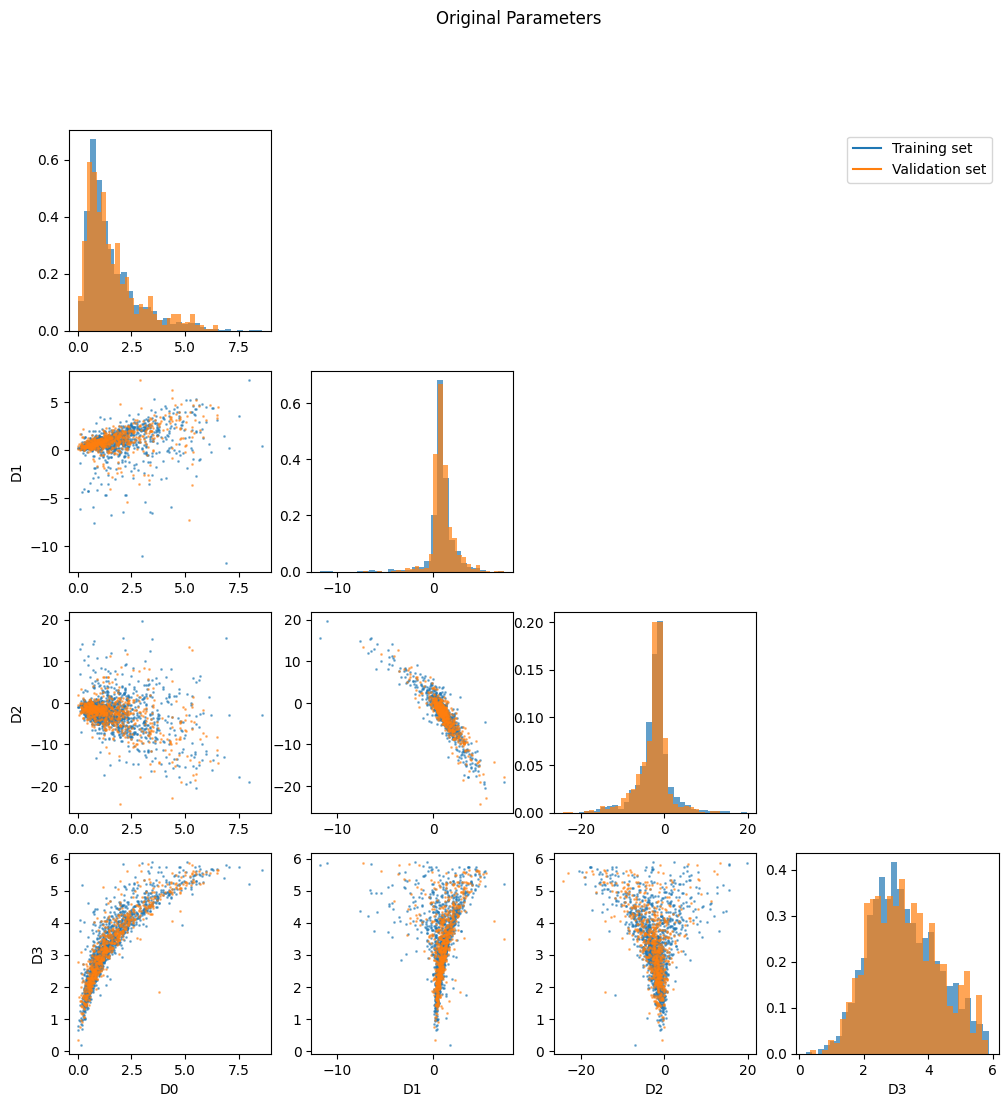

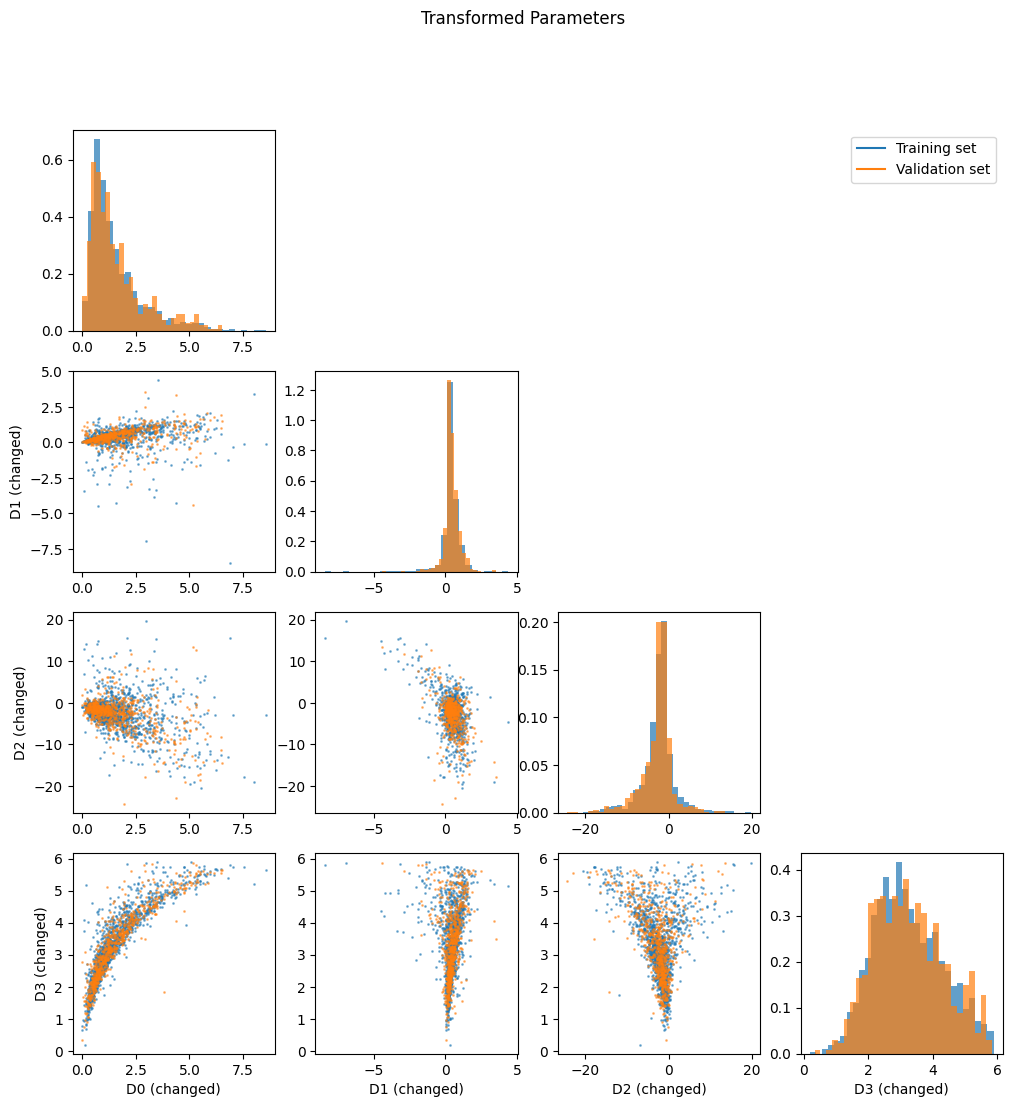

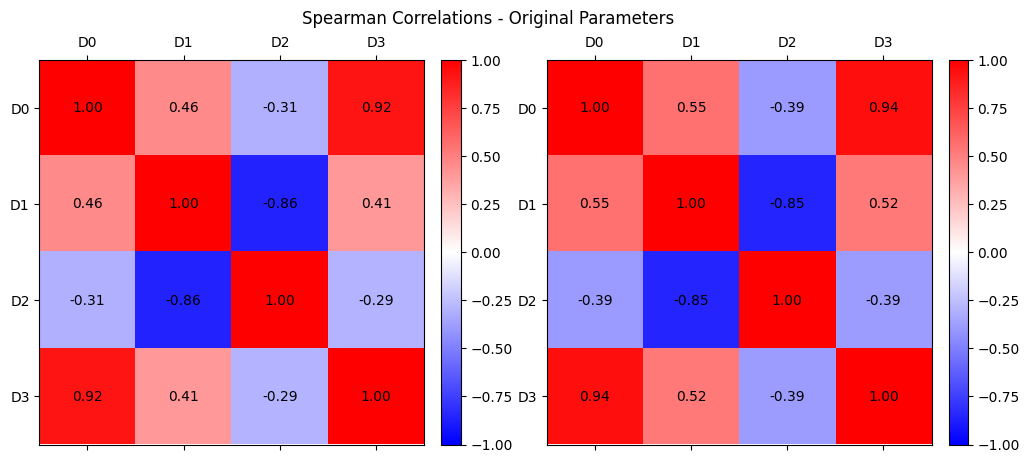

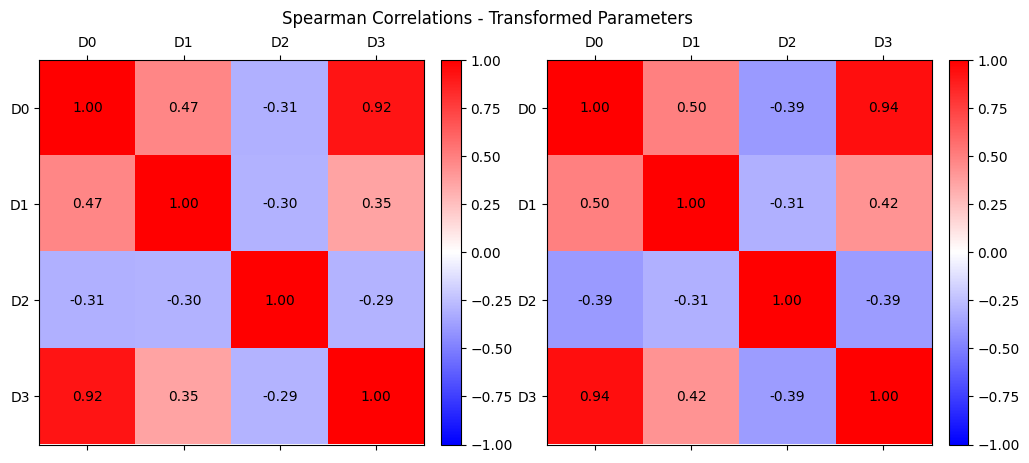

In [33]:
name = 'train'

ini_file = 'conf/iob_44.ini'
args = OperonArgs(ini_file)

# # Use corner, but do scatter plot not contours
# corner.corner(popt_new, labels=['D0', 'D1', 'D2', 'D3'], 
#               show_titles=True, title_fmt='.3f', 
#               plot_contours=True, plot_datapoints=True,
#             #   quantiles=[0.16, 0.5, 0.84],
#               title_kwargs={"fontsize": 12});


fig1 = None # old parameters corner
fig2 = None # changed parameters corner
fig3 = None # old parameters correlation
fig4 = None # changed parameters correlation

for k, name in enumerate(['train', 'val']):

    run_name = f'{args.in_param}_{str(args.version_num)}'
    fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
    df_opt = pd.read_csv(fname_opt)
    popt_new = df_opt[['newpar_D0', 'newpar_D1', 'newpar_D2', 'newpar_D3']].values

    # Remove problematic points
    m = (popt_new[:,0] > 0)
    popt_new = popt_new[m,:]

    # Provide some transformed parameters for better visualisation
    popt_new_changed = popt_new.copy()

    # Find rotation value which minimises correlation between D1 and D2
    def loss_fun(a):
        D1 = popt_new[:,1]
        D2 = popt_new[:,2]
        D1_new = D1 + a * D2
        corr = scipy.stats.spearmanr(D1_new, D2).correlation
        return np.abs(corr)
    
    res = scipy.optimize.minimize_scalar(loss_fun, bounds=(-1.0, 1.0), method='bounded')
    a_opt = res.x
    print(f'Optimal rotation to reduce D1-D2 correlation: {a_opt:.3f}')

    # Try evaluting D1 + D2 x when the other term (b2 + b3 x) is roughly 0, which is
    # when x = - b/b3 ~ 0.209. From above, it turns out that a = 0.26 works well.
    # popt_new_changed[:,1] = popt_new_changed[:,1] + 0.26 * popt_new_changed[:,2]
    popt_new_changed[:,1] = popt_new_changed[:,1] + 0.209 * popt_new_changed[:,2]

    # Rotating D0 and D3
    # D0 = popt_new[:,0]
    # D3 = popt_new[:,3]
    # x = np.log(D0) - 0.173
    # y = D3 - 3.258
    # theta = 0.598
    # popt_new_changed[:,0] = np.cos(theta) * x - np.sin(theta) * y
    # popt_new_changed[:,3] = np.sin(theta) * x + np.cos(theta) * y

    if fig1 is None:
        fig1, axs1 = plt.subplots(popt_new.shape[1], popt_new.shape[1], figsize=(12,12))
        fig2, axs2 = plt.subplots(popt_new.shape[1], popt_new.shape[1], figsize=(12,12))
        fig3, axs3 = plt.subplots(1, 2, figsize=(12,5))
        fig4, axs4 = plt.subplots(1, 2, figsize=(12,5))

    for i in range(popt_new.shape[1]):
        for j in range(popt_new.shape[1]):
            ax1 = axs1[i,j]
            ax2 = axs2[i,j]
            if i == j:
                ax1.hist(popt_new[:,i], bins=30, alpha=0.7, color=f'C{k}', density=True)
                ax2.hist(popt_new_changed[:,i], bins=30, alpha=0.7, color=f'C{k}', density=True)
            elif i > j:
                ax1.scatter(popt_new[:,j], popt_new[:,i], s=1, alpha=0.5, color=f'C{k}')
                ax2.scatter(popt_new_changed[:,j], popt_new_changed[:,i], s=1, alpha=0.5, color=f'C{k}')
            else:
                ax1.axis('off')
                ax2.axis('off')

    # Compute correlation matrices
    # corr_matrix = np.corrcoef(popt_new, rowvar=False)
    corr_matrix, pval_matrix = scipy.stats.spearmanr(popt_new, axis=0)
    # corr_matrix_changed = np.corrcoef(popt_new_changed, rowvar=False)
    corr_matrix_changed, pval_matrix_changed = scipy.stats.spearmanr(popt_new_changed, axis=0)
    im3 = axs3[k].matshow(corr_matrix, vmin=-1, vmax=1, cmap='bwr')
    im4 = axs4[k].matshow(corr_matrix_changed, vmin=-1, vmax=1, cmap='bwr')

    # Print values on the correlation matrices
    for (i, j), val in np.ndenumerate(corr_matrix):
        axs3[k].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')
    for (i, j), val in np.ndenumerate(corr_matrix_changed):
        axs4[k].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')

    # Add colorbars to correlation plots
    fig3.colorbar(im3, ax=axs3[k], fraction=0.046, pad=0.04)
    fig4.colorbar(im4, ax=axs4[k], fraction=0.046, pad=0.04)


# Add legend to upper right plot
for axs in [axs1, axs2]:
    axs[0,-1].plot([], [], color='C0', label='Training set')
    axs[0,-1].plot([], [], color='C1', label='Validation set')
    axs[0,-1].legend()

for i in range(1, popt_new.shape[1]):
    axs1[i,0].set_ylabel(f'D{i}')
    axs2[i,0].set_ylabel(f'D{i} (changed)')
for j in range(popt_new.shape[1]):
    axs1[-1,j].set_xlabel(f'D{j}')
    axs2[-1,j].set_xlabel(f'D{j} (changed)')

xticks = [f'D{i}' for i in range(popt_new.shape[1])]
yticks = [f'D{i}' for i in range(popt_new.shape[1])]
for ax in list(axs3.flatten()) + list(axs4.flatten()):
    ax.set_xticks(np.arange(len(xticks)))
    ax.set_yticks(np.arange(len(yticks)))
    ax.set_xticklabels(xticks)
    ax.set_yticklabels(yticks)

fig1.suptitle('Original Parameters')
fig2.suptitle('Transformed Parameters')
fig3.suptitle('Spearman Correlations - Original Parameters')
fig4.suptitle('Spearman Correlations - Transformed Parameters')


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini
Correlation between D0 and D3: 0.920
Correlation between new D0 and D3: 0.920


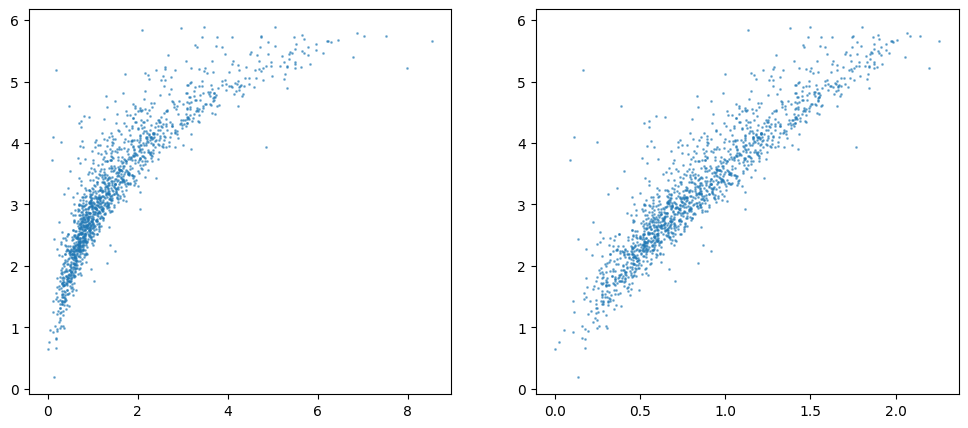

In [29]:
name = 'train'
args = OperonArgs('conf/iob_44.ini')
run_name = f'{args.in_param}_{str(args.version_num)}'
fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
df_opt = pd.read_csv(fname_opt)
popt_new = df_opt[['newpar_D0', 'newpar_D1', 'newpar_D2', 'newpar_D3']].values

D0 = popt_new[:,0]
D3 = popt_new[:,3]

m = D0 > 0
D0 = D0[m]
D3 = D3[m]
corr = scipy.stats.spearmanr(D0, D3).correlation
print(f'Correlation between D0 and D3: {corr:.3f}')

D0_new = np.log(D0)
D3_new = D3
corr = scipy.stats.spearmanr(D0_new, D3_new).correlation
print(f'Correlation between new D0 and D3: {corr:.3f}')

# def loss_fun(theta):
#     x = np.log(D0)
#     x -= np.mean(x)
#     y = D3.copy()
#     y -= np.mean(y)
#     D0_new = np.cos(theta) * x + (-np.sin(theta)) * y
#     D3_new = (np.sin(theta)) * x + np.cos(theta) * y
#     # D0_new = np.cos(theta) * np.log(D0) + np.sin(theta) * D0
#     # D3_new = D3 + (-np.sin(theta)) * np.log(D0) + np.cos(theta) * D0
#     corr = scipy.stats.spearmanr(D0_new, D3_new).correlation
#     return np.abs(corr)

# res = scipy.optimize.minimize_scalar(loss_fun, bounds=(-np.pi, np.pi), method='bounded')
# print(res)
# # a = res.x
# # a = -1.0
# # D0_new = np.log(D0)
# # D3_new = D3 + a * D0
# theta = res.x
# # D0_new = np.cos(theta) * np.log(D0) + np.sin(theta) * D0
# # D3_new = D3 + (-np.sin(theta)) * np.log(D0) + np.cos(theta) * D0
# x = np.log(D0)
# print('Mean log D0:', np.mean(x))
# x -= np.mean(x)
# y = D3.copy()
# print('Mean D3:', np.mean(y))
# y -= np.mean(y)
# D0_new = np.cos(theta) * x + np.sin(theta) * y
# D3_new = (-np.sin(theta)) * x + np.cos(theta) * y
# corr = scipy.stats.spearmanr(D0_new, D3_new).correlation
# print(f'Correlation between new D0 and D3: {corr:.3f}')

D0_new = np.log(1 + D0)
D3_new = D3.copy()

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].plot(D0, D3, marker='.', linestyle='none', alpha=0.5, ms=2)
axs[1].plot(D0_new, D3_new, marker='.', linestyle='none', alpha=0.5, ms=2)

# Reparametrise

In [4]:
b = [1.015638351440429688e+00, -9.222948074340820312e+00, 4.451240158081054688e+01,
         -2.127728118896484375e+02, 4.002230465412139893e-01, 2.856298522949218750e+02]

c = [None] * 5
c[0] = b[4]
c[1] = b[5]
c[2] = - b[2] / b[3]
c[3] = b[1]
c[4] = b[0]

# Round to 4 significant figures
c = [f'{x:.4g}' for x in c]

print(c)

['0.4002', '285.6', '0.2092', '-9.223', '1.016']


Check the RMSE between the old parameterisation and new one is similar


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini


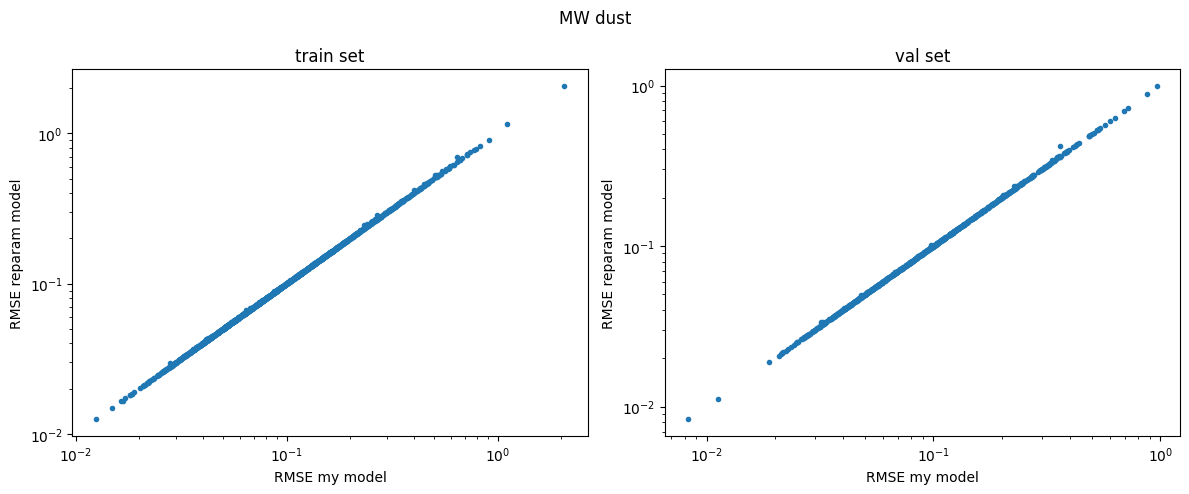

In [6]:
name = 'train'

ini_file = 'conf/iob_44.ini'
args = OperonArgs(ini_file)

fig, axs = plt.subplots(1, 2, figsize=(12,5))

for k, name in enumerate(['train', 'val']):

    run_name = f'{args.in_param}_{str(args.version_num)}'
    fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
    df_opt = pd.read_csv(fname_opt)

    axs[k].loglog(df_opt['rmse_newpar'], df_opt['rmse_newpar_reparam'], '.')

    axs[k].set_xlabel('RMSE my model')
    axs[k].set_ylabel('RMSE reparam model')
    axs[k].set_title(f'{name} set')

fig.suptitle('MW dust')
fig.tight_layout()

Check Correlations in New Parametrisation


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini

Reading from configuration file: conf/iob_47.ini

Reading from configuration file: conf/selection_2.ini


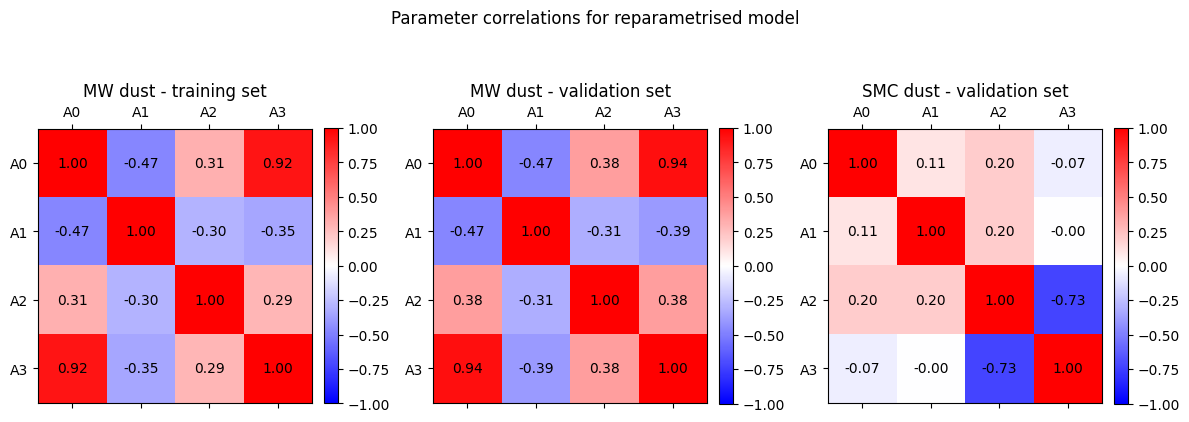

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(12,5))

def get_corr_matrix(args, name):
    run_name = f'{args.in_param}_{str(args.version_num)}'
    fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
    df_opt = pd.read_csv(fname_opt)
    popt_new = df_opt[['newpar_reparam_A0', 'newpar_reparam_A1', 'newpar_reparam_A2', 'newpar_reparam_A3']].values
    corr_matrix, pval_matrix = scipy.stats.spearmanr(popt_new, axis=0)
    return corr_matrix

ini_file = 'conf/iob_44.ini'
args = OperonArgs(ini_file)
corr_matrix_train = get_corr_matrix(args, 'train')
corr_matrix_val = get_corr_matrix(args, 'val')

ini_file = 'conf/iob_47.ini'
args = OperonArgs(ini_file)
corr_matrix_val_SMC = get_corr_matrix(args, 'val')

im0 = axs[0].matshow(corr_matrix_train, vmin=-1, vmax=1, cmap='bwr')
im1 = axs[1].matshow(corr_matrix_val, vmin=-1, vmax=1, cmap='bwr')
im2 = axs[2].matshow(corr_matrix_val_SMC, vmin=-1, vmax=1, cmap='bwr')

# Print values on the correlation matrices
for (i, j), val in np.ndenumerate(corr_matrix_train):
    axs[0].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')
for (i, j), val in np.ndenumerate(corr_matrix_val):
    axs[1].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')
for (i, j), val in np.ndenumerate(corr_matrix_val_SMC):
    axs[2].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')

fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

xticks = [f'A{i}' for i in range(4)]
yticks = [f'A{i}' for i in range(4)]
for ax in axs:
    ax.set_xticks(np.arange(len(xticks)))
    ax.set_yticks(np.arange(len(yticks)))
    ax.set_xticklabels(xticks)
    ax.set_yticklabels(yticks)

axs[0].set_title('MW dust - training set')
axs[1].set_title('MW dust - validation set')
axs[2].set_title('SMC dust - validation set')

fig.suptitle('Parameter correlations for reparametrised model')
fig.tight_layout()
fig.savefig('figs/parameter_correlation_matrices_reparam.png', bbox_inches='tight')

Plot distributions of new parameters


Reading from configuration file: conf/iob_44.ini

Reading from configuration file: conf/selection_1.ini

Reading from configuration file: conf/iob_47.ini

Reading from configuration file: conf/selection_2.ini


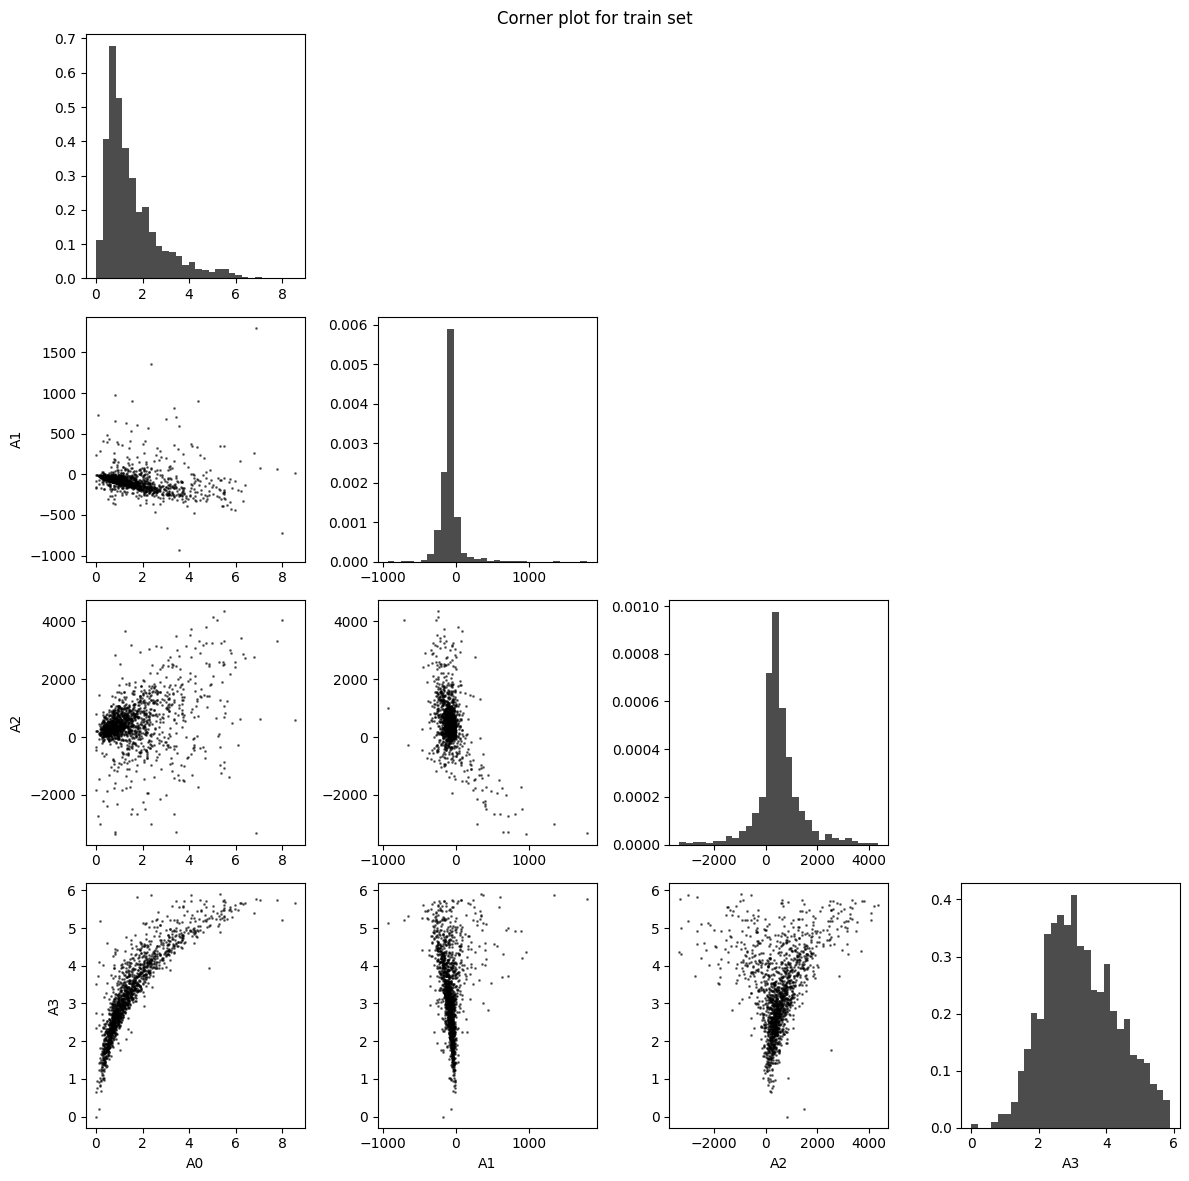

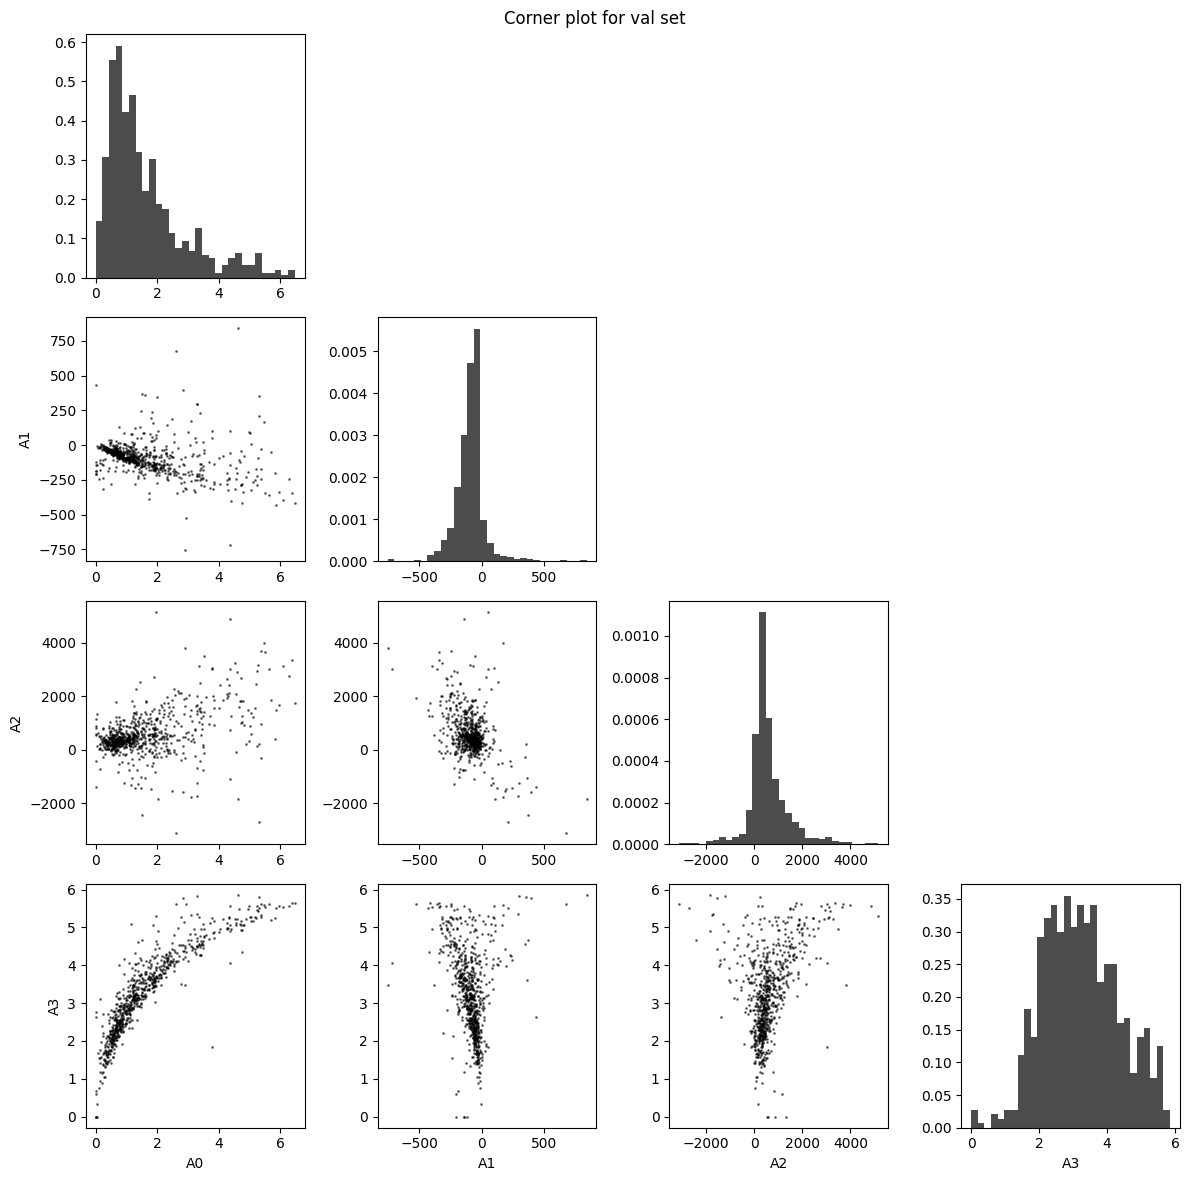

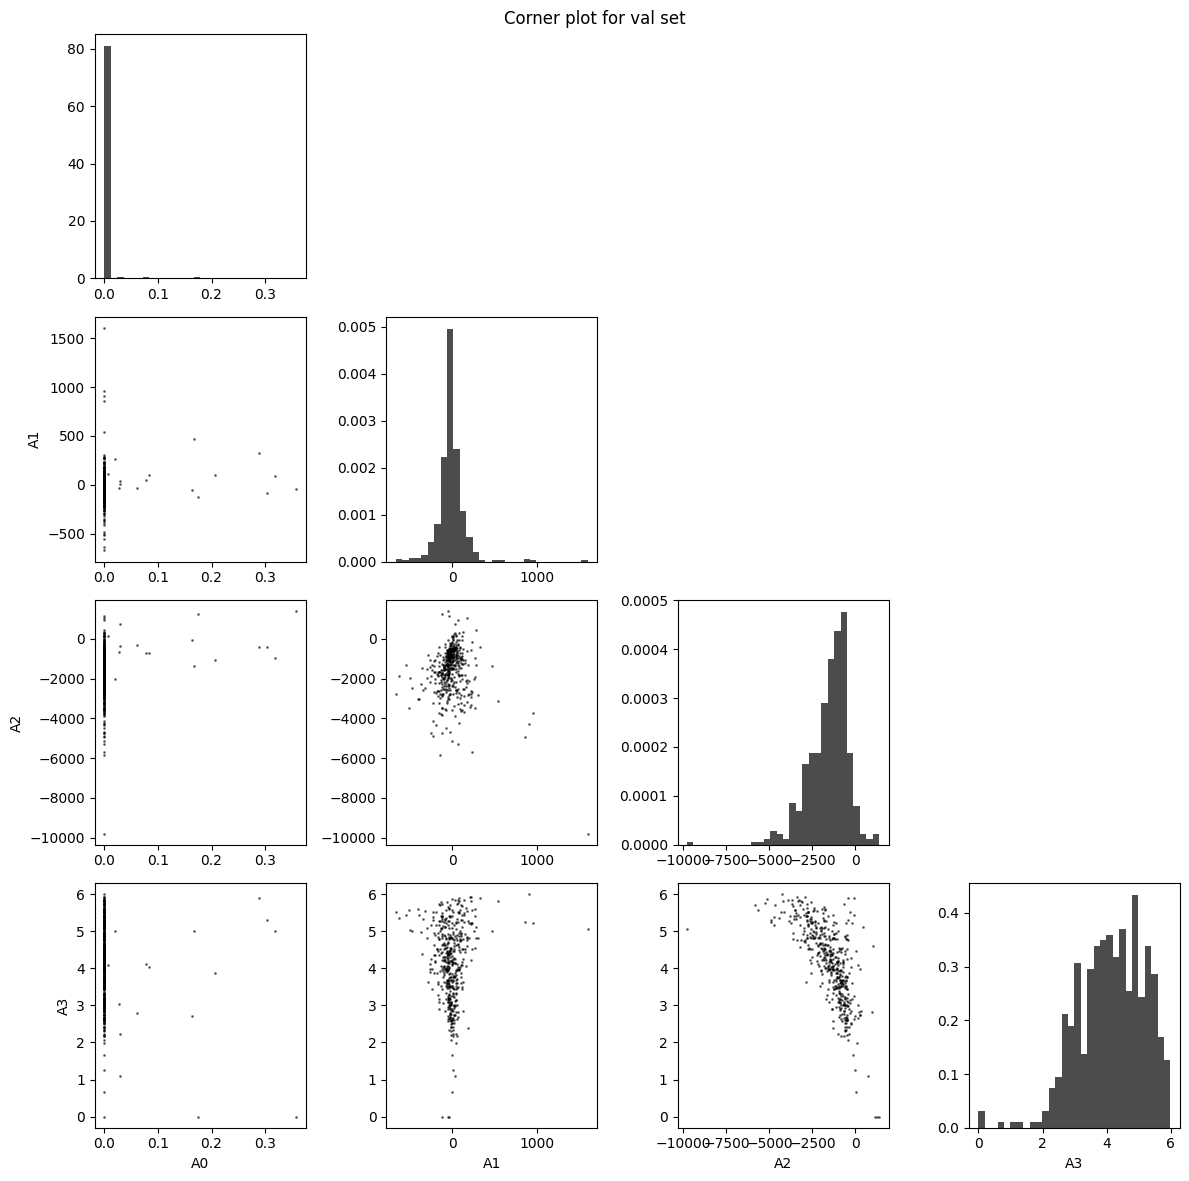

In [8]:
def plot_corner(args, name):

    run_name = f'{args.in_param}_{str(args.version_num)}'
    fname_opt = f'{args.fit_dir}/{run_name}/{run_name}_opt_results_{name}.csv'
    df_opt = pd.read_csv(fname_opt)
    popt_new = df_opt[['newpar_reparam_A0', 'newpar_reparam_A1', 'newpar_reparam_A2', 'newpar_reparam_A3']].values

    fig, axs = plt.subplots(popt_new.shape[1], popt_new.shape[1], figsize=(12,12))

    for i in range(popt_new.shape[1]):
        for j in range(popt_new.shape[1]):
            ax = axs[i,j]
            if i == j:
                ax.hist(popt_new[:,i], bins=30, alpha=0.7, color='k', density=True)
            elif i > j:
                ax.scatter(popt_new[:,j], popt_new[:,i], s=1, alpha=0.5, color='k')
            else:
                ax.axis('off')
    for i in range(1, popt_new.shape[1]):
        axs[i,0].set_ylabel(f'A{i}')
    for j in range(popt_new.shape[1]):
        axs[-1,j].set_xlabel(f'A{j}')

    fig.suptitle(f'Corner plot for {name} set')
    fig.tight_layout()

    return fig

args = OperonArgs('conf/iob_44.ini')
fig_train = plot_corner(args, 'train')
fig_val = plot_corner(args, 'val')
fig_smc = plot_corner(OperonArgs('conf/iob_47.ini'), 'val')
    

* Check various $A_{\rm v}$ values to ensure that the new parametrisation does better in all regimes. Expect that for low $A_{\rm v}$ we do well (common in TNG), but maybe not much better than 2par for the high $A_{\rm v}$. Should be comparable to 2par in that regime and better than all in the other regime
* Check for priors and degneracies of parameters for the new functional form (particularly for the feature-less high $A_{\rm v}$ curves)
* Fit the new dust mixture curves to check we also do better there

# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(46000, 7) (23000, 7)


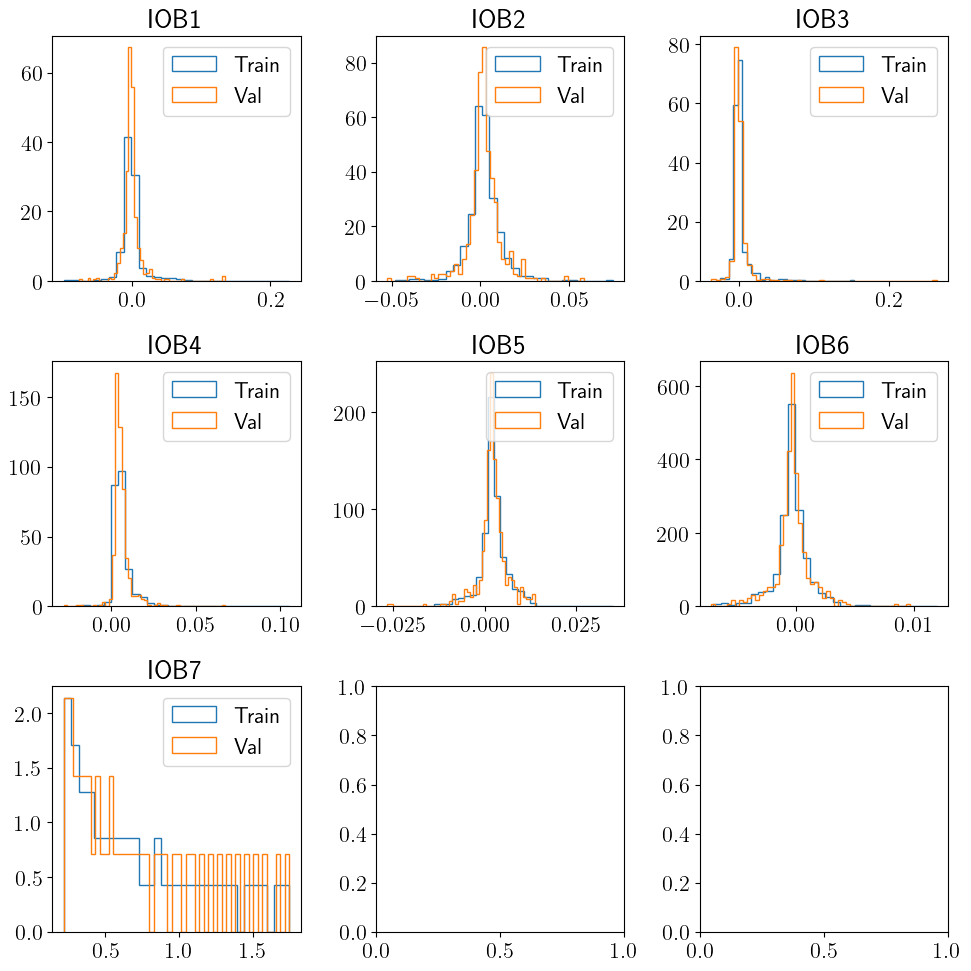

In [114]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()[:X.shape[1]]):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()

# Look at distribution of IOB parameter combinations


Reading from configuration file: conf/iob_6.ini

Reading from configuration file: conf/selection_0.ini
-5369.777802441621 138992.38562712393 533.9560958773085 5.14299100909797


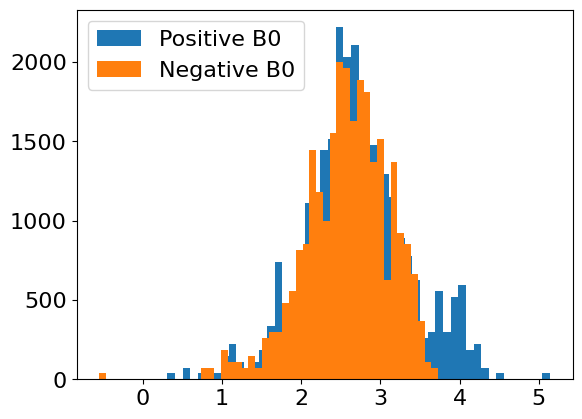

In [18]:
ini_file = 'conf/iob_6.ini';
args = OperonArgs(ini_file)
dirname = pjoin(args.out_data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
data = pd.read_csv(fname_train, sep=r'\s+')

c = [0.999999, 5.160664, 14.21899, 96.767336287521, 346.455505, 418.237518, 308.280884, 64.732704, 69744.210938, 20.115023, 0.989066010925, 0.999999, 2.638054, 7.050597, 91.976021, 4.946947, 0.441919, 0.045192, 1391.598999, 182.675049, 3.984417, 7.549686, 0.985602, 6.911434, 2.567828]
IOB1 = data['IOB1'].values
IOB2 = data['IOB2'].values
IOB3 = data['IOB3'].values
B0 = -c[0]*(-IOB2**2*c[3]*(-IOB1*c[4] - IOB2*c[5] - IOB3*c[6] + c[7])**2 - IOB3*c[8])

print(B0.min(), B0.max(), B0.mean(), np.log10(np.abs(B0)).max())

m = B0 > 0
plt.hist(np.log10(B0[m]), bins=50, label='Positive B0')
plt.hist(np.log10(-B0[~m]), bins=50, label='Negative B0')
plt.legend()

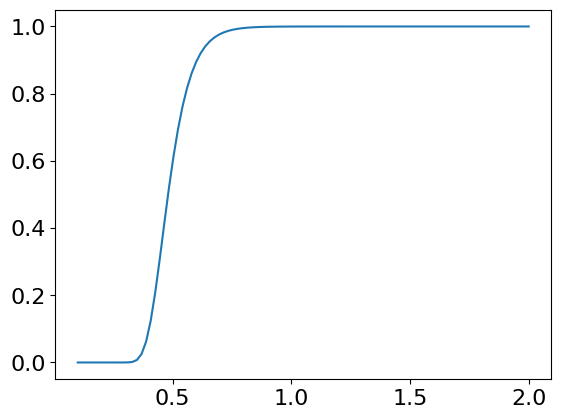

In [31]:
x = np.linspace(0.1, 2, 100)
a8 = -5908.80419900000
a10 = -17.3103690000000
y = np.exp(a8 * x * np.exp(a10 * x))
plt.plot(x, y)